In [1]:
"""
HAM10000 XAI Robustness Study

This notebook compares:
1. ResNet18 with Grad-CAM
2. ViT-Tiny with attention rollout

The experiment evaluates baseline classification performance, prediction
robustness, and explanation robustness under controlled test-time
perturbations.
"""
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

torch.cuda.empty_cache()


## Dataset

Download the HAM10000 dataset from Kaggle:

https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000

In [2]:
import pandas as pd

# path to the CSV file with metadata about the images
META_PATH = r'HAM10000_metadata.csv'
df = pd.read_csv(META_PATH)
print("Metadata loaded. Shape:", df.shape)
df.head()


Metadata loaded. Shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
# list image files in both folders after unzip
IMG_DIR1 = r'HAM10000_images_part_1'
IMG_DIR2 = r'HAM10000_images_part_2'

# Read the filenames from both folders
image_files_1 = set(os.listdir(IMG_DIR1))
image_files_2 = set(os.listdir(IMG_DIR2))
#combine all images into one set
all_image_files = image_files_1.union(image_files_2)

# Check for missing images
# Check whether every image listed in the metadata is available
missing_images = []
for img_id in df['image_id']:
    fname = img_id + '.jpg'
    if fname not in all_image_files:
        missing_images.append(fname)

if not missing_images:
    print("All images referenced in metadata are present in the folders.")
else:
    print(f"Missing images: {len(missing_images)}")
    print(missing_images[:10])  # missing images 


All images referenced in metadata are present in the folders.


Unique diagnosis codes: <ArrowStringArray>
['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
Length: 7, dtype: str
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


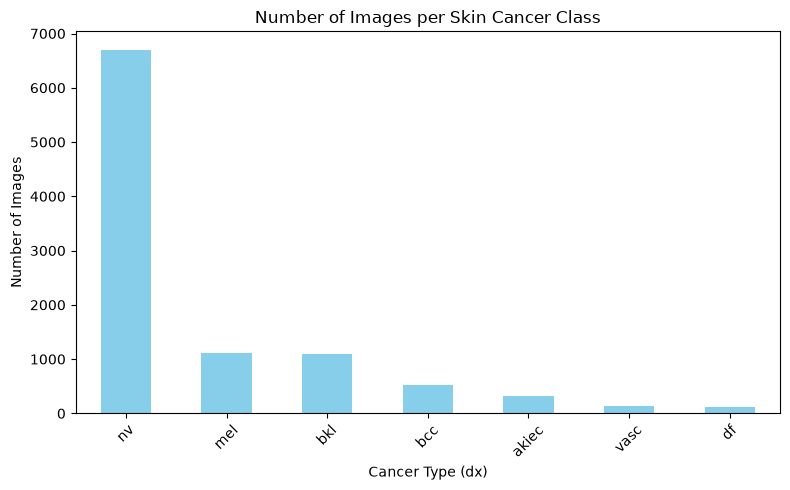

In [4]:
import matplotlib.pyplot as plt

# check the column with diagnostic labels (dx)
print("Unique diagnosis codes:", df['dx'].unique())

# count per class
class_counts = df['dx'].value_counts()
print(class_counts)

# Plot as a bar chart
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color='skyblue')
plt.title("Number of Images per Skin Cancer Class")
plt.xlabel("Cancer Type (dx)")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [5]:
from sklearn.model_selection import train_test_split
# Fixed seed makes the split reproducible

SEED = 42

# Use lesion_id to prevent images of the same lesion appearing in different splits
split_col = 'lesion_id'

# Each lesion is a splitting unit. HAM10000 metadata normally assigns one diagnosis to each lesion.
lesion_table = df[[split_col, 'dx']].drop_duplicates()
# Check that every lesion is associated with only one diagnosis
labels_per_lesion = lesion_table.groupby(split_col)['dx'].nunique()
assert labels_per_lesion.max() == 1, "A lesion has more than one diagnosis; inspect metadata before splitting."
lesion_table = lesion_table.drop_duplicates(subset=[split_col])

# 15% test; then 15% of the remaining lesions for validation.
train_val_lesions, test_lesions = train_test_split(
    lesion_table,
    test_size=0.15,
    random_state=SEED,
    stratify=lesion_table['dx']
)
train_lesions, val_lesions = train_test_split(
    train_val_lesions,
    test_size=0.15,
    random_state=SEED,
    stratify=train_val_lesions['dx']
)

split_map = {}
split_map.update(dict.fromkeys(train_lesions[split_col], 'train'))
split_map.update(dict.fromkeys(val_lesions[split_col], 'val'))
split_map.update(dict.fromkeys(test_lesions[split_col], 'test'))
df['split'] = df[split_col].map(split_map)

assert df['split'].notna().all()
assert set(train_lesions[split_col]).isdisjoint(set(val_lesions[split_col]))
assert set(train_lesions[split_col]).isdisjoint(set(test_lesions[split_col]))
assert set(val_lesions[split_col]).isdisjoint(set(test_lesions[split_col]))

print(df['split'].value_counts())
print(df.groupby(['split', 'dx']).size().unstack(fill_value=0))


split
train    7238
test     1490
val      1287
Name: count, dtype: int64
dx     akiec  bcc  bkl  df  mel    nv  vasc
split                                      
test      45   75  164  21  159  1001    25
train    238  376  782  84  811  4849    98
val       44   63  153  10  143   855    19


In [6]:
from sklearn.preprocessing import LabelEncoder
#label encoder object to turn text labels into numbers
le = LabelEncoder()
#convert the 'dx' column (diagnosis names) into numbers and store in 'label_idx'
df['label_idx'] = le.fit_transform(df['dx'])
class_names = le.classes_
num_classes = len(class_names)
print("Classes:", list(class_names))


Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [7]:
class SkinLesionDataset(Dataset):
    def __init__(self, df, img_dir1, img_dir2, split='train', transform=None):
        self.df = df[df['split'] == split].reset_index(drop=True)
        self.img_dir1 = img_dir1
        self.img_dir2 = img_dir2
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def image_path(self, idx):
        filename = self.df.iloc[idx]['image_id'] + '.jpg'
        path = os.path.join(self.img_dir1, filename)
        return path if os.path.exists(path) else os.path.join(self.img_dir2, filename)

    def __getitem__(self, idx):
        image = Image.open(self.image_path(idx)).convert('RGB')
        label = int(self.df.iloc[idx]['label_idx'])
        if self.transform:
            image = self.transform(image)
        return image, label

# ImageNet statistics match the pretrained torchvision/timm models.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Deliberately identical deterministic preprocessing for train, validation, and baseline test.
train_dataset = SkinLesionDataset(df, IMG_DIR1, IMG_DIR2, split='train', transform=base_transform)
val_dataset = SkinLesionDataset(df, IMG_DIR1, IMG_DIR2, split='val', transform=base_transform)
test_dataset = SkinLesionDataset(df, IMG_DIR1, IMG_DIR2, split='test', transform=base_transform)

PIN_MEMORY = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=PIN_MEMORY)


In [8]:
#single batch from the train_loader
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 5 labels:", labels[:5])


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 5 labels: tensor([5, 5, 2, 5, 5])


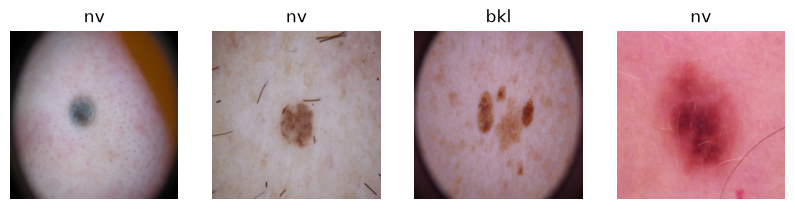

In [ ]:
import matplotlib.pyplot as plt

def imshow(img, title=None):
    """Display a normalized image after reversing ImageNet normalization."""

    # Recreate the mean and standard deviation used during image normalization
    mean = torch.tensor(IMAGENET_MEAN)[:, None, None]
    std = torch.tensor(IMAGENET_STD)[:, None, None]

    # Undo normalization and keep pixel values within the valid display range
    img = (img.cpu() * std + mean).clamp(0, 1)

    # Convert the tensor from channel-first to image format for Matplotlib
    plt.imshow(img.permute(1, 2, 0).numpy())

    if title:
        plt.title(title)

    # Hide axis markings for a cleaner image display
    plt.axis('off')


# Display four sample images with their corresponding class labels
plt.figure(figsize=(10, 4))

for i in range(4):
    plt.subplot(1, 4, i + 1)
    imshow(images[i], class_names[labels[i]])

plt.show()

In [ ]:
# Display the number of batches available in each dataset split
print("Train batches:", len(train_loader))

print("Validation batches:", len(val_loader))

print("Test batches:", len(test_loader))

Train batches: 227
Validation batches: 41
Test batches: 47


In [11]:
#!pip install timm

In [ ]:
import timm
import torch
import torch.nn as nn
from torchvision import models

# Use a GPU when CUDA is available; otherwise fall back to the CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Define the pretrained models to be compared in the project
model_configs = {
    'resnet18': {
        'type': 'cnn',
        'init_fn': lambda: models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    },
    'vit_tiny_patch16_224': {
        'type': 'vit',
        'init_fn': lambda: timm.create_model('vit_tiny_patch16_224', pretrained=True)
    }
}

# Initialize each pretrained model and replace its classification head
# so that it produces predictions for the project's diagnostic classes
for model_name, cfg in model_configs.items():
    model = cfg['init_fn']()

    if cfg['type'] == 'cnn':
        # Replace the ResNet18 fully connected layer with a 7-class output layer
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    else:
        # Replace the ViT classification head with an output layer for the target classes
        model.reset_classifier(num_classes=num_classes)

        # Disable fused attention so attention maps can be extracted
        # for the ViT explainability analysis
        for block in model.blocks:
            if hasattr(block.attn, 'fused_attn'):
                block.attn.fused_attn = False

    # Move the initialized model to the selected computation device
    cfg['model'] = model.to(device)

# Display the models included in the CNN vs ViT comparison
print('Compared models:', list(model_configs))

c:\Users\kotak\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Compared models: ['resnet18', 'vit_tiny_patch16_224']


In [ ]:
# Verify the selected device and display GPU information when CUDA is available
print("Device:", device)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
# Count training images for each encoded diagnostic class
train_class_counts = (
    df.loc[df['split'] == 'train', 'label_idx']
      .value_counts()
      .reindex(range(num_classes), fill_value=0)
      .sort_index()
)

# Ensure that every diagnostic class is represented in the training split
if (train_class_counts == 0).any():
    raise ValueError(f"Training split is missing classes: {train_class_counts[train_class_counts == 0].index.tolist()}")

# Calculate inverse-frequency class weights to reduce the effect of class imbalance
class_weights = len(df[df['split'] == 'train']) / (num_classes * train_class_counts.to_numpy())

# Convert the weights to a tensor on the selected computation device
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

# Display each class, its training-image count, and its corresponding loss weight
print(pd.DataFrame({'class': class_names, 'train_images': train_class_counts.values,
                    'loss_weight': class_weights.cpu().numpy()}))


   class  train_images  loss_weight
0  akiec           238     4.344538
1    bcc           376     2.750000
2    bkl           782     1.322251
3     df            84    12.309524
4    mel           811     1.274969
5     nv          4849     0.213240
6   vasc            98    10.551021


In [ ]:
import copy
from sklearn.metrics import f1_score

def train_model(model, train_loader, val_loader, class_weights, num_epochs=5, lr=1e-4):
    """Train a model and retain the weights with the best validation macro F1-score."""

    # Use Adam optimization and weighted cross-entropy to account for class imbalance
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Initialize the best validation score and save the model's initial weights
    best_val_macro_f1 = -1.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        # Set the model to training mode
        model.train()
        running_loss, running_corrects = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Clear gradients from the previous optimization step
            optimizer.zero_grad()

            # Generate predictions and calculate the weighted training loss
            outputs = model(inputs)

            # Average spatial outputs when the model returns more than two dimensions
            if outputs.ndim > 2:
                outputs = outputs.view(outputs.size(0), outputs.size(1), -1).mean(-1)

            loss = criterion(outputs, labels)

            # Backpropagate the loss and update model parameters
            loss.backward()
            optimizer.step()

            # Calculate training predictions and accumulate loss and correct predictions
            preds = outputs.argmax(dim=1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += (preds == labels).sum().item()

        # Calculate average training loss and accuracy for the current epoch
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects / len(train_loader.dataset)

        # Evaluate the model on the validation set without calculating gradients
        model.eval()
        val_labels, val_preds = [], []

        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs.to(device))

                # Average spatial outputs when the model returns more than two dimensions
                if outputs.ndim > 2:
                    outputs = outputs.view(outputs.size(0), outputs.size(1), -1).mean(-1)

                val_preds.extend(outputs.argmax(1).cpu().numpy())
                val_labels.extend(labels.numpy())

        # Calculate validation accuracy and macro F1-score
        val_acc = np.mean(np.asarray(val_preds) == np.asarray(val_labels))
        val_macro_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)

        print(f"Epoch {epoch+1}/{num_epochs}: loss={epoch_loss:.4f}, train_acc={epoch_acc:.4f}, "
              f"val_acc={val_acc:.4f}, val_macro_f1={val_macro_f1:.4f}")

        # Keep the model weights from the epoch with the highest validation macro F1-score
        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_model_wts = copy.deepcopy(model.state_dict())

    # Restore the best-performing validation model before returning it
    model.load_state_dict(best_model_wts)
    print(f"Best validation macro F1: {best_val_macro_f1:.4f}")

    return model


# Train each model using the same training and validation setup
trained_models = {}

for model_name, cfg in model_configs.items():
    print(f"\nTraining {model_name.upper()}")

    trained_models[model_name] = train_model(
        cfg['model'], train_loader, val_loader, class_weights, num_epochs=5, lr=1e-4
    )



Training RESNET18
Epoch 1/5: loss=1.0600, train_acc=0.6112, val_acc=0.6402, val_macro_f1=0.5450
Epoch 2/5: loss=0.4374, train_acc=0.7881, val_acc=0.7172, val_macro_f1=0.5977
Epoch 3/5: loss=0.2485, train_acc=0.8511, val_acc=0.7560, val_macro_f1=0.5970
Epoch 4/5: loss=0.1071, train_acc=0.9257, val_acc=0.8050, val_macro_f1=0.6465
Epoch 5/5: loss=0.0988, train_acc=0.9344, val_acc=0.7817, val_macro_f1=0.6455
Best validation macro F1: 0.6465

Training VIT_TINY_PATCH16_224
Epoch 1/5: loss=1.4515, train_acc=0.5431, val_acc=0.7249, val_macro_f1=0.5227
Epoch 2/5: loss=0.8631, train_acc=0.6779, val_acc=0.6309, val_macro_f1=0.4731
Epoch 3/5: loss=0.6435, train_acc=0.7204, val_acc=0.5726, val_macro_f1=0.4958
Epoch 4/5: loss=0.3816, train_acc=0.7900, val_acc=0.7110, val_macro_f1=0.5542
Epoch 5/5: loss=0.2721, train_acc=0.8328, val_acc=0.7576, val_macro_f1=0.6313
Best validation macro F1: 0.6313



RESNET18 BASELINE (ORIGINAL TEST SET)
model                   RESNET18
accuracy                0.785235
balanced_accuracy       0.638329
macro_f1                0.600028
weighted_f1              0.78508
macro_ovr_roc_auc       0.941754
weighted_ovr_roc_auc    0.926833


,precision,recall,f1-score,support
akiec,0.386667,0.644444,0.483333,45.0
bcc,0.750000,0.400000,0.521739,75.0
bkl,0.722222,0.554878,0.627586,164.0
df,0.313725,0.761905,0.444444,21.0
mel,0.500000,0.477987,0.488746,159.0
nv,0.890411,0.909091,0.899654,1001.0
vasc,0.750000,0.720000,0.734694,25.0


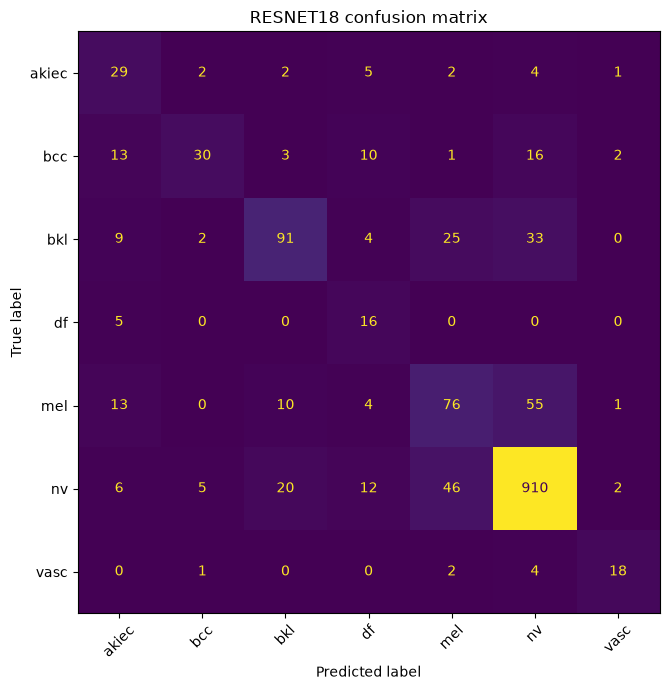


VIT_TINY_PATCH16_224 BASELINE (ORIGINAL TEST SET)
model                   VIT_TINY_PATCH16_224
accuracy                            0.732886
balanced_accuracy                     0.6209
macro_f1                            0.579522
weighted_f1                         0.754589
macro_ovr_roc_auc                   0.947581
weighted_ovr_roc_auc                0.937709


,precision,recall,f1-score,support
akiec,0.347826,0.711111,0.467153,45.0
bcc,0.690909,0.506667,0.584615,75.0
bkl,0.526066,0.676829,0.592000,164.0
df,0.458333,0.523810,0.488889,21.0
mel,0.392593,0.666667,0.494172,159.0
nv,0.952497,0.781219,0.858397,1001.0
vasc,0.705882,0.480000,0.571429,25.0


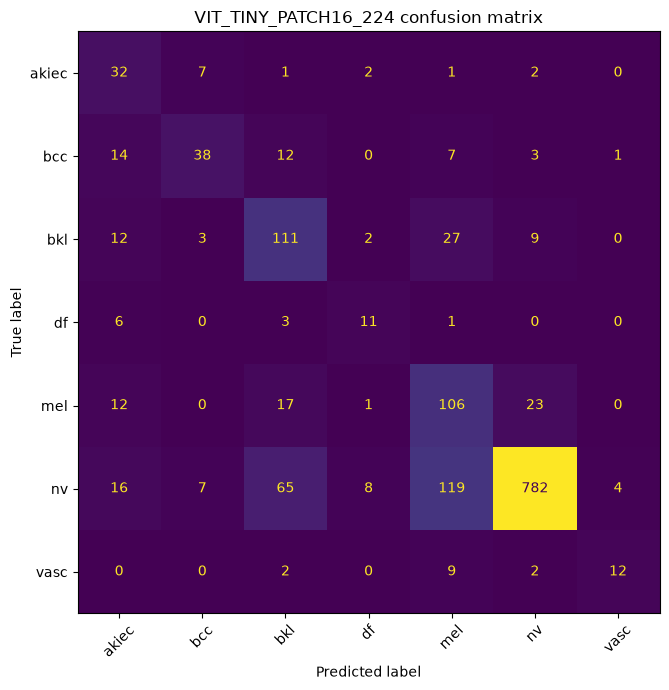

,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_ovr_roc_auc,weighted_ovr_roc_auc
model,,,,,,
RESNET18,0.785235,0.638329,0.600028,0.785080,0.941754,0.926833
VIT_TINY_PATCH16_224,0.732886,0.620900,0.579522,0.754589,0.947581,0.937709


In [ ]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize


def collect_predictions(model, loader):
    """Collect true labels, predicted labels, and class probabilities from a data loader."""

    # Switch the model to evaluation mode and prepare containers for predictions
    model.eval()
    labels_all, preds_all, probs_all = [], [], []

    # Disable gradient calculation because this step is used only for evaluation
    with torch.no_grad():
        for inputs, labels in loader:
            # Generate model outputs for the current batch
            outputs = model(inputs.to(device))

            # Average spatial outputs when the model returns more than two dimensions
            if outputs.ndim > 2:
                outputs = outputs.view(outputs.size(0), outputs.size(1), -1).mean(-1)

            # Convert model outputs into class probabilities
            probs = torch.softmax(outputs, dim=1)

            # Store labels, predicted classes, and probabilities for all batches
            labels_all.extend(labels.numpy())
            preds_all.extend(probs.argmax(1).cpu().numpy())
            probs_all.extend(probs.cpu().numpy())

    return np.asarray(labels_all), np.asarray(preds_all), np.asarray(probs_all)


def evaluate_and_plot(model, loader, class_names, model_name=''):
    """Evaluate a model using classification metrics and display its confusion matrix."""

    # Collect predictions and probabilities for the evaluation dataset
    y_true, y_pred, y_prob = collect_predictions(model, loader)
    labels = np.arange(len(class_names))

    # Calculate the main overall classification metrics
    summary = {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0),
    }

    # Calculate one-vs-rest ROC-AUC metrics across all diagnostic classes
    try:
        summary['macro_ovr_roc_auc'] = roc_auc_score(
            y_true, y_prob, labels=labels, multi_class='ovr', average='macro'
        )
        summary['weighted_ovr_roc_auc'] = roc_auc_score(
            y_true, y_prob, labels=labels, multi_class='ovr', average='weighted'
        )

    # Record missing ROC-AUC values if the metric cannot be calculated
    except ValueError as exc:
        summary['macro_ovr_roc_auc'] = np.nan
        summary['weighted_ovr_roc_auc'] = np.nan
        print('ROC-AUC unavailable:', exc)

    # Generate detailed precision, recall, F1-score, and support for each class
    report = classification_report(
        y_true, y_pred, labels=labels, target_names=class_names,
        output_dict=True, zero_division=0
    )

    per_class = pd.DataFrame(report).T.loc[class_names, ['precision', 'recall', 'f1-score', 'support']]

    # Display overall and per-class evaluation results
    print(pd.Series(summary).to_string())
    display(per_class)

    # Calculate and display the confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(8, 7))

    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, xticks_rotation=45, colorbar=False
    )

    ax.set_title(f'{model_name} confusion matrix')
    plt.tight_layout()
    plt.show()

    return summary, per_class, (y_true, y_pred, y_prob)


# Evaluate each trained model on the original, unmodified test set
baseline_results, baseline_per_class, baseline_predictions = [], {}, {}

for model_name, model in trained_models.items():
    print(f"\n{model_name.upper()} BASELINE (ORIGINAL TEST SET)")

    summary, per_class, predictions = evaluate_and_plot(
        model, test_loader, class_names, model_name.upper()
    )

    baseline_results.append(summary)
    baseline_per_class[model_name] = per_class
    baseline_predictions[model_name] = predictions


# Combine the baseline evaluation summaries into a single comparison table
baseline_results_df = pd.DataFrame(baseline_results).set_index('model')
display(baseline_results_df)


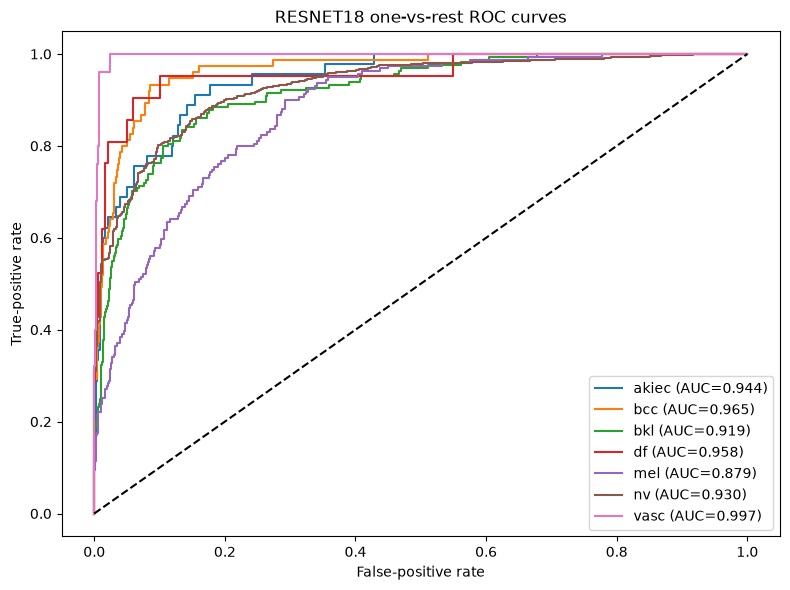

,ROC-AUC
akiec,0.944468
bcc,0.965239
bkl,0.919265
df,0.958443
mel,0.878684
nv,0.929647
vasc,0.996532


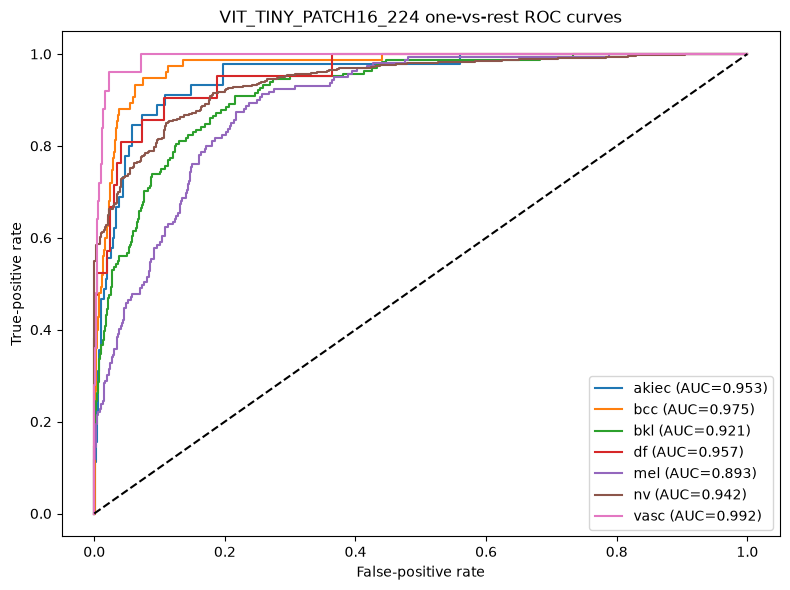

,ROC-AUC
akiec,0.953341
bcc,0.974558
bkl,0.920860
df,0.956530
mel,0.893375
nv,0.942295
vasc,0.992109


In [ ]:
def plot_multiclass_roc_from_predictions(y_true, y_prob, class_names, model_name):
    """Plot one-vs-rest ROC curves and calculate ROC-AUC for each diagnostic class."""

    # Create numerical labels corresponding to the diagnostic classes
    labels = np.arange(len(class_names))

    # Convert multiclass labels into a binary one-vs-rest representation
    y_binary = label_binarize(y_true, classes=labels)
    per_class_auc = {}

    # Create the ROC plot for all diagnostic classes
    plt.figure(figsize=(8, 6))

    for i, class_name in enumerate(class_names):
        # Skip ROC-AUC calculation when a class has only one binary outcome
        if np.unique(y_binary[:, i]).size < 2:
            per_class_auc[class_name] = np.nan
            continue

        # Calculate the false-positive and true-positive rates for the class
        fpr, tpr, _ = roc_curve(y_binary[:, i], y_prob[:, i])

        # Calculate the area under the ROC curve
        per_class_auc[class_name] = auc(fpr, tpr)

        # Plot the one-vs-rest ROC curve and include its AUC in the legend
        plt.plot(fpr, tpr, label=f'{class_name} (AUC={per_class_auc[class_name]:.3f})')

    # Add the diagonal reference line representing chance-level classification
    plt.plot([0, 1], [0, 1], 'k--')

    # Add plot labels and formatting
    plt.title(f'{model_name} one-vs-rest ROC curves')
    plt.xlabel('False-positive rate')
    plt.ylabel('True-positive rate')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return pd.Series(per_class_auc, name='ROC-AUC')


# Calculate and display per-class ROC-AUC values for each trained model
baseline_auc_per_class = {}

for model_name, (y_true, _, y_prob) in baseline_predictions.items():
    baseline_auc_per_class[model_name] = plot_multiclass_roc_from_predictions(
        y_true, y_prob, class_names, model_name.upper()
    )

    display(baseline_auc_per_class[model_name].to_frame())


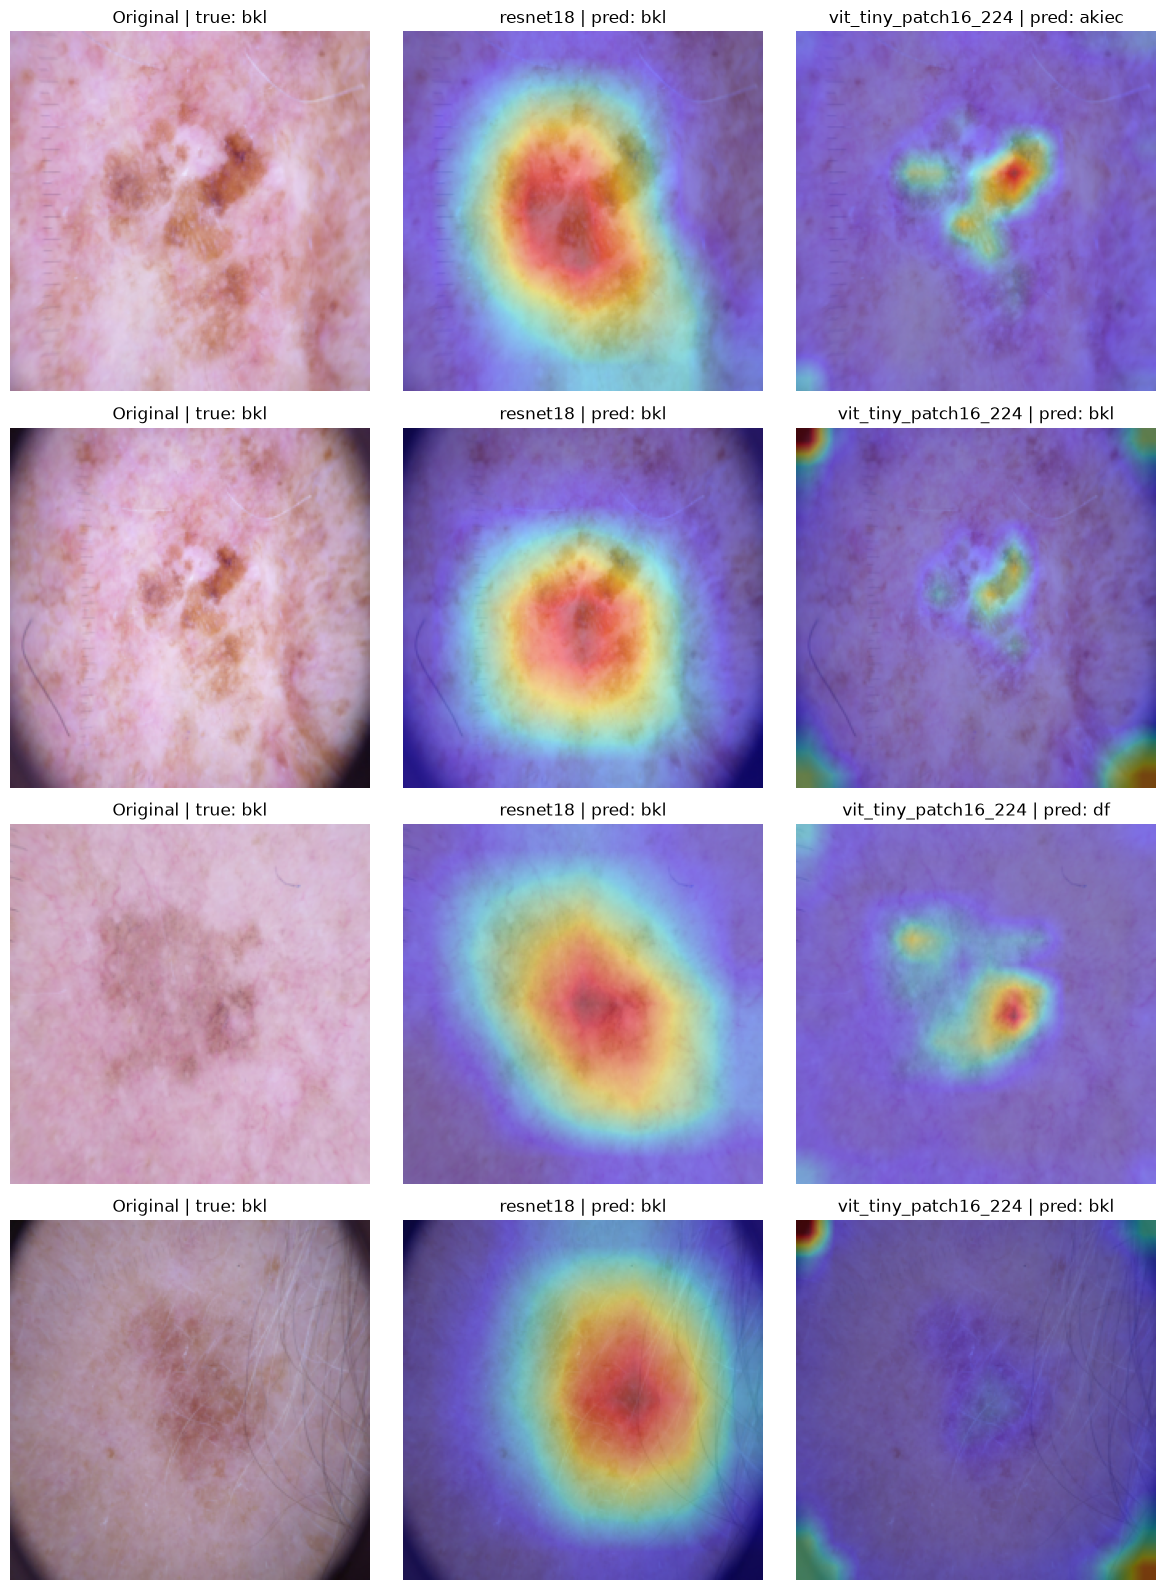

In [ ]:
import torch.nn.functional as F


def normalize_heatmap(heatmap):
    """Normalize a heatmap to the range [0, 1]."""

    # Shift the minimum value to zero before scaling
    heatmap = heatmap.float()
    heatmap = heatmap - heatmap.min()

    # Avoid division by zero for a constant heatmap
    return heatmap / heatmap.max().clamp_min(1e-8)


def resnet18_gradcam(model, input_tensor, class_idx=None):
    """Generate a Grad-CAM heatmap for a ResNet18 model."""

    activations, gradients = {}, {}

    # Capture the feature activations and their gradients from the final convolutional block
    def forward_hook(_module, _inputs, output):
        activations['value'] = output
        output.register_hook(lambda grad: gradients.update(value=grad))

    # Register the hook used to obtain the activations and gradients
    handle = model.layer4.register_forward_hook(forward_hook)

    model.eval()
    model.zero_grad(set_to_none=True)

    # Generate the model prediction
    logits = model(input_tensor)

    # Use the model's predicted class when no target class is provided
    if class_idx is None:
        class_idx = int(logits.argmax(1).item())

    # Backpropagate the selected class score to obtain Grad-CAM gradients
    logits[0, class_idx].backward()
    handle.remove()

    # Calculate channel weights from the spatially averaged gradients
    weights = gradients['value'].mean(dim=(2, 3), keepdim=True)

    # Combine the weighted feature maps and retain positive activations
    cam = torch.relu((weights * activations['value']).sum(dim=1, keepdim=True))

    # Resize the heatmap to the original 224 x 224 image dimensions
    cam = F.interpolate(
        cam, size=(224, 224), mode='bilinear', align_corners=False
    )[0, 0]

    return normalize_heatmap(cam.detach().cpu()), class_idx


def vit_attention_rollout(model, input_tensor, class_idx=None):
    """Generate an attention-rollout heatmap for a Vision Transformer."""

    captured = []
    handles = []

    # Pre-hooks calculate the same attention probabilities from each block's input.
    def make_hook(attn_module):
        def hook(_module, inputs):
            x = inputs[0]
            batch, tokens, channels = x.shape

            # Reconstruct the query, key, and value tensors used by the attention block
            qkv = attn_module.qkv(x).reshape(
                batch, tokens, 3, attn_module.num_heads, channels // attn_module.num_heads
            ).permute(2, 0, 3, 1, 4)

            q, k = qkv[0], qkv[1]

            # Calculate the attention probabilities for the current transformer block
            attention = (q @ k.transpose(-2, -1)) * attn_module.scale
            captured.append(attention.softmax(dim=-1).detach())

        return hook

    # Register an attention hook for every transformer block
    for block in model.blocks:
        handles.append(block.attn.register_forward_pre_hook(make_hook(block.attn)))

    model.eval()

    # Generate the model prediction while collecting attention information
    with torch.no_grad():
        logits = model(input_tensor)

    # Remove all registered hooks after attention extraction
    for handle in handles:
        handle.remove()

    # Use the model's predicted class when no target class is provided
    if class_idx is None:
        class_idx = int(logits.argmax(1).item())

    # Initialize the attention rollout with the identity matrix
    rollout = torch.eye(
        captured[0].shape[-1], device=captured[0].device
    ).unsqueeze(0)

    # Combine attention information across all transformer blocks
    for attention in captured:
        attention = attention.mean(dim=1)
        attention = attention + torch.eye(
            attention.shape[-1], device=attention.device
        ).unsqueeze(0)
        attention = attention / attention.sum(dim=-1, keepdim=True)
        rollout = attention @ rollout

    # Extract attention from the class token to the image patch tokens
    patch_attention = rollout[0, 0, 1:]

    # Convert the patch-level attention values into a spatial heatmap
    side = int(np.sqrt(patch_attention.numel()))
    heatmap = patch_attention.reshape(1, 1, side, side)

    # Resize the patch heatmap to the original 224 x 224 image dimensions
    heatmap = F.interpolate(
        heatmap, size=(224, 224), mode='bilinear', align_corners=False
    )[0, 0]

    return normalize_heatmap(heatmap.cpu()), class_idx


def explain(model_name, model, input_tensor, class_idx=None):
    """Generate an explanation heatmap using the method associated with a model."""

    # Use Grad-CAM for the CNN and attention rollout for the Vision Transformer
    if model_name == 'resnet18':
        return resnet18_gradcam(model, input_tensor, class_idx)

    if model_name == 'vit_tiny_patch16_224':
        return vit_attention_rollout(model, input_tensor, class_idx)

    # Raise an error if an unsupported model name is supplied
    raise KeyError(model_name)


def denormalize_image(tensor):
    """Reverse ImageNet normalization for displaying an image."""

    # Recreate the mean and standard deviation used during image preprocessing
    mean = torch.tensor(IMAGENET_MEAN)[:, None, None]
    std = torch.tensor(IMAGENET_STD)[:, None, None]

    # Reverse normalization and constrain values to the valid image range
    return (tensor.cpu() * std + mean).clamp(0, 1)


# Qualitative baseline check on original test images.
n_examples = min(4, len(test_dataset))
fig, axes = plt.subplots(
    n_examples, 3, figsize=(12, 4 * n_examples), squeeze=False
)

for row in range(n_examples):
    image, label = test_dataset[row]

    # Display the original test image and its true diagnostic class
    axes[row, 0].imshow(denormalize_image(image).permute(1, 2, 0))
    axes[row, 0].set_title(f'Original | true: {class_names[label]}')
    axes[row, 0].axis('off')

    for col, model_name in enumerate(
        ['resnet18', 'vit_tiny_patch16_224'], start=1
    ):
        # Generate an explanation and prediction for the current model
        heatmap, predicted = explain(
            model_name,
            trained_models[model_name],
            image.unsqueeze(0).to(device)
        )

        # Overlay the explanation heatmap on the original image
        axes[row, col].imshow(denormalize_image(image).permute(1, 2, 0))
        axes[row, col].imshow(heatmap, cmap='jet', alpha=0.4)

        # Display the model name and predicted diagnostic class
        axes[row, col].set_title(
            f'{model_name} | pred: {class_names[predicted]}'
        )
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()


Prediction robustness: resnet18
  Running rotate_-5deg
  Running rotate_+5deg
  Running horizontal_flip
  Running brightness_0.9
  Running brightness_1.1
  Running gaussian_blur

Prediction robustness: vit_tiny_patch16_224
  Running rotate_-5deg
  Running rotate_+5deg
  Running horizontal_flip
  Running brightness_0.9
  Running brightness_1.1
  Running gaussian_blur


prediction_agreement  \
model                perturbation                            
resnet18             rotate_-5deg                 0.897987   
                     rotate_+5deg                 0.887248   
                     horizontal_flip              0.871812   
                     brightness_0.9               0.926174   
                     brightness_1.1               0.923490   
                     gaussian_blur                0.905369   
vit_tiny_patch16_224 rotate_-5deg                 0.855705   
                     rotate_+5deg                 0.865101   
                     horizontal_flip              0.883893   
                     brightness_0.9               0.911409   
                     brightness_1.1               0.910067   
                     gaussian_blur                0.969799   

                                      prediction_change_rate  \
model                perturbation                              
resnet18             rotate_-5deg                   0.102013   
                     rotate_+5deg                   0.112752   
                     horizontal_flip                0.128188   
                     brightness_0.9                 0.073826   
                     brightness_1.1                 0.076510   
                     gaussian_blur                  0.094631   
vit_tiny_patch16_224 rotate_-5deg                   0.144295   
                     rotate_+5deg                   0.134899   
                     horizontal_flip                0.116107   
                     brightness_0.9                 0.088591   
                     brightness_1.1                 0.089933   
                     gaussian_blur                  0.030201   

                                      macro_class_agreement  \
model                perturbation                             
resnet18             rotate_-5deg                  0.839099   
                     rotate_+5deg                  0.842596   
                     horizontal_flip               0.798552   
                     brightness_0.9                0.863134   
                     brightness_1.1                0.889557   
                     gaussian_blur                 0.846025   
vit_tiny_patch16_224 rotate_-5deg                  0.789847   
                     rotate_+5deg                  0.794731   
                     horizontal_flip               0.805003   
                     brightness_0.9                0.832955   
                     brightness_1.1                0.876604   
                     gaussian_blur                 0.955455   

                                      mean_absolute_confidence_change  \
model                perturbation                                       
resnet18             rotate_-5deg                            0.093735   
                     rotate_+5deg                            0.096072   
                     horizontal_flip                         0.106936   
                     brightness_0.9                          0.066396   
                     brightness_1.1                          0.059922   
                     gaussian_blur                           0.068163   
vit_tiny_patch16_224 rotate_-5deg                            0.131563   
                     rotate_+5deg                            0.119396   
                     horizontal_flip                         0.086951   
                     brightness_0.9                          0.073574   
                     brightness_1.1                          0.073710   
                     gaussian_blur                           0.026790   

                                      correct_to_incorrect_rate  \
model                perturbation                                 
resnet18             rotate_-5deg                      0.041611   
                     rotate_+5deg                      0.049664   
                     horizontal_flip                   0.055034   
                     brightness

akiec       bcc       bkl        df  \
model                perturbation                                              
resnet18             rotate_-5deg     0.822222  0.706667  0.823171  1.000000   
                     rotate_+5deg     0.844444  0.653333  0.786585  1.000000   
                     horizontal_flip  0.888889  0.666667  0.762195  0.761905   
                     brightness_0.9   0.822222  0.706667  0.853659  0.857143   
                     brightness_1.1   0.977778  0.800000  0.780488  0.952381   
                     gaussian_blur    0.888889  0.813333  0.713415  0.904762   
vit_tiny_patch16_224 rotate_-5deg     0.644444  0.680000  0.804878  0.904762   
                     rotate_+5deg     0.644444  0.680000  0.835366  0.904762   
                     horizontal_flip  0.800000  0.706667  0.847561  0.809524   
                     brightness_0.9   0.688889  0.746667  0.878049  0.809524   
                     brightness_1.1   0.888889  0.786667  0.871951  0.904762   
                     gaussian_blur    1.000000  0.933333  0.932927  0.952381   

                                           mel        nv  vasc  
model                perturbation                               
resnet18             rotate_-5deg     0.773585  0.948052  0.80  
                     rotate_+5deg     0.798742  0.935065  0.88  
                     horizontal_flip  0.742138  0.928072  0.84  
                     brightness_0.9   0.874214  0.968032  0.96  
                     brightness_1.1   0.874214  0.962038  0.88  
                     gaussian_blur    0.798742  0.963037  0.84  
vit_tiny_patch16_224 rotate_-5deg     0.798742  0.896104  0.80  
                     rotate_+5deg     0.792453  0.906094  0.80  
                     horizontal_flip  0.830189  0.921079  0.72  
                     brightness_0.9   0.880503  0.947053  0.88  
                     brightness_1.1   0.823899  0.940060  0.92  
                     gaussian_blur    0.924528  0.985015  0.96

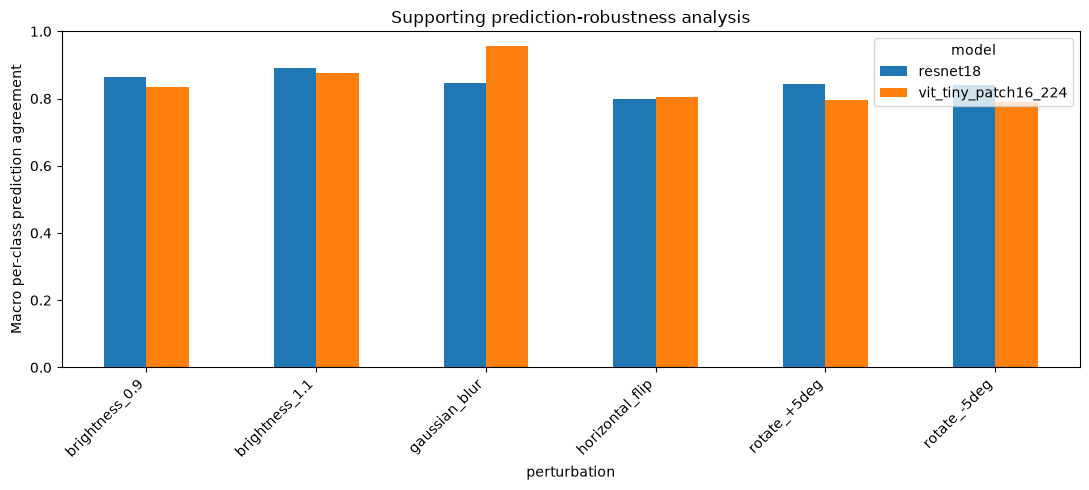

In [ ]:
from torchvision.transforms import functional as TF
from torchvision.transforms.functional import InterpolationMode


# Define the image perturbations used to test prediction robustness
PERTURBATIONS = {
    "rotate_-5deg": lambda image: TF.rotate(
        image, -5,
        interpolation=InterpolationMode.BILINEAR,
        fill=0
    ),
    "rotate_+5deg": lambda image: TF.rotate(
        image, 5,
        interpolation=InterpolationMode.BILINEAR,
        fill=0
    ),
    "horizontal_flip": TF.hflip,
    "brightness_0.9": lambda image: TF.adjust_brightness(
        image, 0.9
    ),
    "brightness_1.1": lambda image: TF.adjust_brightness(
        image, 1.1
    ),
    "gaussian_blur": lambda image: TF.gaussian_blur(
        image, kernel_size=5, sigma=1.0
    )
}


class PerturbedTestDataset(Dataset):
    """Apply a specified image perturbation to samples from the test dataset."""

    def __init__(self, base_dataset, perturbation):
        self.base_dataset = base_dataset
        self.perturbation = perturbation

    def __len__(self):
        """Return the number of samples in the base test dataset."""
        return len(self.base_dataset)

    def __getitem__(self, idx):
        """Load, perturb, transform, and return a test image with its label."""

        # Load the original image and ensure it has three RGB channels
        image = Image.open(
            self.base_dataset.image_path(idx)
        ).convert("RGB")

        # Apply the selected robustness perturbation before model preprocessing
        image = self.perturbation(image)
        image = base_transform(image)

        # Retrieve the original diagnostic label
        label = int(
            self.base_dataset.df.iloc[idx]["label_idx"]
        )

        return image, label


def prediction_robustness_metrics(
    y_true,
    original_pred,
    original_prob,
    perturbed_pred,
    perturbed_prob
):
    """Calculate metrics describing prediction changes after image perturbation."""

    # Check whether the predicted class remains unchanged after perturbation
    prediction_stable = perturbed_pred == original_pred

    # Track whether each prediction is correct before and after perturbation
    original_correct = original_pred == y_true
    perturbed_correct = perturbed_pred == y_true

    # Create row indices for retrieving the relevant class probabilities
    rows = np.arange(len(y_true))

    # Record the original prediction confidence for each sample
    original_confidence = original_prob[
        rows, original_pred
    ]

    # Measure perturbed confidence for the original predicted class
    perturbed_confidence = perturbed_prob[
        rows, original_pred
    ]

    # Calculate the change in confidence for the original predicted class
    confidence_change = (
        perturbed_confidence - original_confidence
    )

    # Calculate prediction agreement separately for each true class
    per_class_agreement = {}

    for class_idx, class_name in enumerate(class_names):
        class_mask = y_true == class_idx

        per_class_agreement[class_name] = (
            prediction_stable[class_mask].mean()
            if np.any(class_mask)
            else np.nan
        )

    # Combine the main prediction-robustness measures into one result
    result = {
        "prediction_agreement":
            prediction_stable.mean(),

        "prediction


XAI robustness: resnet18 (20 images)
  Image 1/20
  Image 10/20
  Image 20/20

XAI robustness: vit_tiny_patch16_224 (20 images)
  Image 1/20
  Image 10/20
  Image 20/20


,image_index,model,perturbation,class,label_idx,original_prediction,perturbed_prediction,prediction_stable,heatmap_correlation,heatmap_cosine,top20_iou
0,0,resnet18,rotate_-5deg,bkl,2,bkl,bkl,True,0.968916,0.986465,0.834567
1,0,resnet18,rotate_+5deg,bkl,2,bkl,bkl,True,0.898422,0.958590,0.749346
2,0,resnet18,horizontal_flip,bkl,2,bkl,bkl,True,0.901544,0.949937,0.651609
3,0,resnet18,brightness_0.9,bkl,2,bkl,bkl,True,0.945228,0.976749,0.736032
4,0,resnet18,brightness_1.1,bkl,2,bkl,bkl,True,0.977096,0.988813,0.792143
5,0,resnet18,gaussian_blur,bkl,2,bkl,bkl,True,0.989410,0.995075,0.887708
6,1,resnet18,rotate_-5deg,bkl,2,bkl,bkl,True,0.899268,0.953382,0.686156
7,1,resnet18,rotate_+5deg,bkl,2,bkl,bkl,True,0.940564,0.968791,0.786242
8,1,resnet18,horizontal_flip,bkl,2,bkl,bkl,True,0.969467,0.985442,0.834064
9,1,resnet18,brightness_0.9,bkl,2,bkl,bkl,True,0.982975,0.991890,0.858174


samples  prediction_agreement  \
model                perturbation    class                                  
resnet18             brightness_0.9  bkl         20                  0.85   
                     brightness_1.1  bkl         20                  0.75   
                     gaussian_blur   bkl         20                  0.75   
                     horizontal_flip bkl         20                  0.80   
                     rotate_+5deg    bkl         20                  0.75   
                     rotate_-5deg    bkl         20                  0.90   
vit_tiny_patch16_224 brightness_0.9  bkl         20                  0.90   
                     brightness_1.1  bkl         20                  0.95   
                     gaussian_blur   bkl         20                  0.85   
                     horizontal_flip bkl         20                  0.80   
                     rotate_+5deg    bkl         20                  0.80   
                     rotate_-5deg    bkl         20                  0.75   

                                            heatmap_correlation  \
model                perturbation    class                        
resnet18             brightness_0.9  bkl               0.987254   
                     brightness_1.1  bkl               0.978999   
                     gaussian_blur   bkl               0.972851   
                     horizontal_flip bkl               0.841128   
                     rotate_+5deg    bkl               0.923547   
                     rotate_-5deg    bkl               0.912818   
vit_tiny_patch16_224 brightness_0.9  bkl               0.996814   
                     brightness_1.1  bkl               0.996984   
                     gaussian_blur   bkl               0.999696   
                     horizontal_flip bkl               0.966344   
                     rotate_+5deg    bkl               0.599665   
                     rotate_-5deg    bkl               0.606544   

                                            heatmap_cosine  top20_iou  
model                perturbation    class                             
resnet18             brightness_0.9  bkl          0.994139   0.883556  
                     brightness_1.1  bkl          0.989953   0.856870  
                     gaussian_blur   bkl          0.986239   0.831049  
                     horizontal_flip bkl          0.941655   0.580281  
                     rotate_+5deg    bkl          0.968382   0.725637  
                     rotate_-5deg    bkl          0.965000   0.733228  
vit_tiny_patch16_224 brightness_0.9  bkl          0.997732   0.935279  
                     brightness_1.1  bkl          0.997646   0.933103  
                     gaussian_blur   bkl          0.999829   0.974742  
                     horizontal_flip bkl          0.981387   0.767623  
                     rotate_+5deg    bkl          0.769537   0.451449  
                     rotate_-5deg    bkl          0.776272   0.452066

prediction_agreement  \
model                perturbation                            
resnet18             brightness_0.9                   0.85   
                     brightness_1.1                   0.75   
                     gaussian_blur                    0.75   
                     horizontal_flip                  0.80   
                     rotate_+5deg                     0.75   
                     rotate_-5deg                     0.90   
vit_tiny_patch16_224 brightness_0.9                   0.90   
                     brightness_1.1                   0.95   
                     gaussian_blur                    0.85   
                     horizontal_flip                  0.80   
                     rotate_+5deg                     0.80   
                     rotate_-5deg                     0.75   

                                      heatmap_correlation  heatmap_cosine  \
model                perturbation                                           
resnet18             brightness_0.9              0.987254        0.994139   
                     brightness_1.1              0.978999        0.989953   
                     gaussian_blur               0.972851        0.986239   
                     horizontal_flip             0.841128        0.941655   
                     rotate_+5deg                0.923547        0.968382   
                     rotate_-5deg                0.912818        0.965000   
vit_tiny_patch16_224 brightness_0.9              0.996814        0.997732   
                     brightness_1.1              0.996984        0.997646   
                     gaussian_blur               0.999696        0.999829   
                     horizontal_flip             0.966344        0.981387   
                     rotate_+5deg                0.599665        0.769537   
                     rotate_-5deg                0.606544        0.776272   

                                      top20_iou  
model                perturbation                
resnet18             brightness_0.9    0.883556  
                     brightness_1.1    0.856870  
                     gaussian_blur     0.831049  
                     horizontal_flip   0.580281  
                     rotate_+5deg      0.725637  
                     rotate_-5deg      0.733228  
vit_tiny_patch16_224 brightness_0.9    0.935279  
                     brightness_1.1    0.933103  
                     gaussian_blur     0.974742  
                     horizontal_flip   0.767623  
                     rotate_+5deg      0.451449  
                     rotate_-5deg      0.452066

Main XAI result: explanation stability when prediction remains unchanged


heatmap_correlation  heatmap_cosine  \
model                perturbation                                           
resnet18             brightness_0.9              0.987177        0.994093   
                     brightness_1.1              0.985910        0.994061   
                     gaussian_blur               0.982413        0.992202   
                     horizontal_flip             0.811576        0.932077   
                     rotate_+5deg                0.913180        0.964559   
                     rotate_-5deg                0.907662        0.963356   
vit_tiny_patch16_224 brightness_0.9              0.997267        0.998133   
                     brightness_1.1              0.996860        0.997552   
                     gaussian_blur               0.999687        0.999823   
                     horizontal_flip             0.963674        0.980317   
                     rotate_+5deg                0.615067        0.785044   
                     rotate_-5deg                0.593551        0.766856   

                                      top20_iou  
model                perturbation                
resnet18             brightness_0.9    0.889343  
                     brightness_1.1    0.867150  
                     gaussian_blur     0.849335  
                     horizontal_flip   0.530673  
                     rotate_+5deg      0.703133  
                     rotate_-5deg      0.728957  
vit_tiny_patch16_224 brightness_0.9    0.935570  
                     brightness_1.1    0.936077  
                     gaussian_blur     0.974464  
                     horizontal_flip   0.766573  
                     rotate_+5deg      0.464542  
                     rotate_-5deg      0.459702

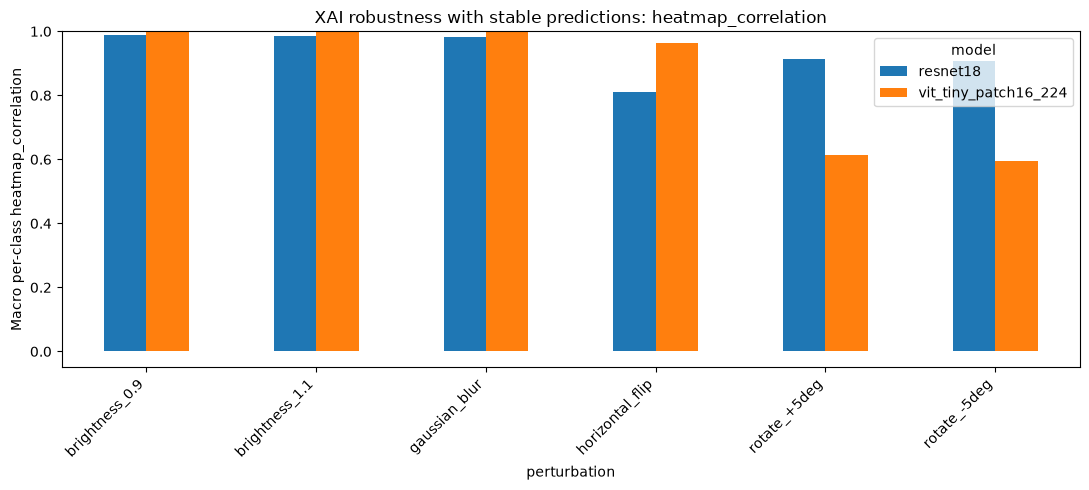

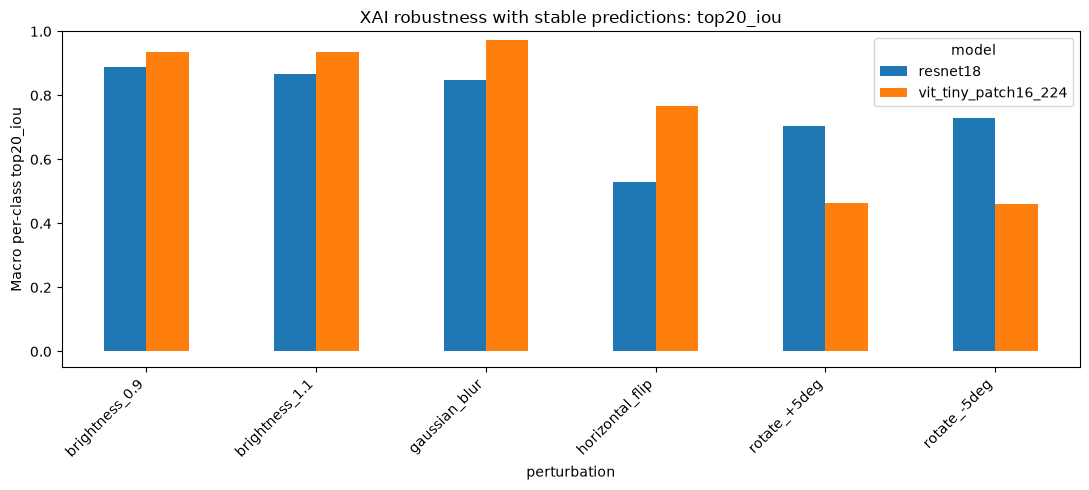

In [ ]:
import torch.nn.functional as F


# Set to None to evaluate all test images; otherwise limit the XAI analysis
XAI_MAX_SAMPLES = None

# Fraction of the highest-valued heatmap region used for overlap comparison
TOP_REGION_FRACTION = 0.20


def inverse_align_heatmap(
    heatmap,
    perturbation_name
):
    """Undo geometric perturbations so explanations can be compared spatially."""

    # Add a batch dimension because torchvision functional transforms expect it
    heatmap = heatmap.unsqueeze(0)

    if perturbation_name == "horizontal_flip":
        # Reverse the horizontal flip applied to the input image
        aligned = TF.hflip(heatmap)

    elif perturbation_name == "rotate_-5deg":
        # Undo the original -5 degree rotation
        aligned = TF.rotate(
            heatmap,
            5,
            interpolation=InterpolationMode.BILINEAR,
            fill=0
        )

    elif perturbation_name == "rotate_+5deg":
        # Undo the original +5 degree rotation
        aligned = TF.rotate(
            heatmap,
            -5,
            interpolation=InterpolationMode.BILINEAR,
            fill=0
        )

    else:
        # Brightness and blur do not move image coordinates
        aligned = heatmap

    # Normalize after spatial alignment for consistent heatmap comparison
    return normalize_heatmap(
        aligned.squeeze(0)
    )


def heatmap_similarity(
    original_heatmap,
    aligned_heatmap,
    top_fraction=0.20
):
    """Measure similarity between original and perturbation-aligned explanations."""

    # Flatten heatmaps so global similarity measures can be calculated
    original = original_heatmap.flatten().float()
    aligned = aligned_heatmap.flatten().float()

    # Measure directional similarity between the two explanation maps
    cosine = F.cosine_similarity(
        original.unsqueeze(0),
        aligned.unsqueeze(0)
    ).item()

    # Center both heatmaps before calculating correlation
    original_centered = original - original.mean()
    aligned_centered = aligned - aligned.mean()

    denominator = torch.sqrt(
        original_centered.square().sum()
        * aligned_centered.square().sum()
    )

    correlation = (
        (
            original_centered
            * aligned_centered
        ).sum()
        / denominator.clamp_min(1e-8)
    ).item()

    # Identify the highest-valued regions containing the specified heatmap fraction
    original_threshold = torch.quantile(
        original,
        1 - top_fraction
    )

    aligned_threshold = torch.quantile(
        aligned,
        1 - top_fraction
    )

    original_mask = original >= original_threshold
    aligned_mask = aligned >= aligned_threshold

    # Calculate overlap between the most important regions of both explanations
    intersection = (
        original_mask & aligned_mask
    ).sum().item()

    union = (
        original_mask | aligned_mask
    ).sum().item()

    top20_iou = (
        intersection / union
        if union > 0
        else np.nan
    )

    return correlation, cosine, top20_iou


def predict_one(model, tensor):
    """Return the predicted class index for a single input tensor."""

    # Evaluation mode and no-gradient inference are sufficient for prediction
    model.eval()

    with torch.no_grad():
        probabilities = torch.softmax(
            model(tensor),
            dim=1
        )

    return int(
        probabilities.argmax(dim=1).item()
    )


# Determine how many test images will be used for the XAI robustness analysis
if XAI_MAX_SAMPLES is None:
    sample_count = len(test_dataset)
else:
    sample_count = min(
        XAI_MAX_SAMPLES,
        len(test_dataset)
    )


xai_rows = []

# Run the XAI robustness analysis separately for each model architecture
for model_name in [
    "resnet18",
    "vit_tiny_patch16_224"
]:
    model = trained_models[model_name]

    print(
        f"\nXAI robustness: {model_name} "
        f"({sample_count} images)"
    )

    # Process the selected test images in their original dataset order
    for idx in range(sample_count):
        if (
            idx == 0
            or (idx + 1) % 10 == 0
            or idx + 1 == sample_count
        ):
            print(
                f"  Image {idx + 1}/{sample_count}"
            )

        # Load the unmodified test image as the reference input
        raw_image = Image.open(
            test_dataset.image_path(idx)
        ).convert("RGB")

        # Retrieve the ground-truth diagnostic label
        true_label = int(
            test_dataset.df.iloc[idx]["label_idx"]
        )

        # Apply the standard model preprocessing to the original image
        original_tensor = base_transform(
            raw_image
        ).unsqueeze(0).to(device)

        # Use the model's original prediction as the explanation target
        original_prediction = predict_one(
            model,
            original_tensor
        )

        # Generate the reference explanation for the original image
        original_heatmap, _ = explain(
            model_name,
            model,
            original_tensor,
            class_idx=original_prediction
        )

        # Evaluate how the explanation changes under each perturbation
        for perturbation_name, perturbation_fn in PERTURBATIONS.items():
            # Apply the same perturbation used in the prediction-robustness analysis
            perturbed_image = perturbation_fn(
                raw_image.copy()
            )

            # Apply the standard preprocessing after perturbation
            perturbed_tensor = base_transform(
                perturbed_image
            ).unsqueeze(0).to(device)

            # Obtain the model prediction after perturbation
            perturbed_prediction = predict_one(
                model,
                perturbed_tensor
            )

            # Grad-CAM uses the same original target class.
            # Attention rollout is class-agnostic.
            perturbed_heatmap, _ = explain(
                model_name,
                model,
                perturbed_tensor,
                class_idx=original_prediction
            )

            # Undo geometric changes before comparing spatial explanations
            aligned_heatmap = inverse_align_heatmap(
                perturbed_heatmap,
                perturbation_name
            )

            # Compare the original and aligned perturbed explanations
            (
                correlation,
                cosine,
                top20_iou
            ) = heatmap_similarity(
                original_heatmap,
                aligned_heatmap,
                TOP_REGION_FRACTION
            )

            # Store prediction and explanation stability for this image
            xai_rows.append({
                "image_index": idx,
                "model": model_name,
                "perturbation": perturbation_name,
                "class": class_names[true_label],
                "label_idx": true_label,

                "original_prediction":
                    class_names[original_prediction],

                "perturbed_prediction":
                    class_names[perturbed_prediction],

                "prediction_stable":
                    original_prediction
                    == perturbed_prediction,

                "heatmap_correlation": correlation,
                "heatmap_cosine": cosine,
                "top20_iou": top20_iou
            })


# Convert the image-level XAI robustness results into a DataFrame
xai_raw_df = pd.DataFrame(xai_rows)

display(xai_raw_df.head(20))


# Aggregate XAI stability separately for each diagnostic class
xai_per_class_df = (
    xai_raw_df
    .groupby([
        "model",
        "perturbation",
        "class"
    ])
    .agg(
        samples=("class", "size"),

        prediction_agreement=(
            "prediction_stable",
            "mean"
        ),

        heatmap_correlation=(
            "heatmap_correlation",
            "mean"
        ),

        heatmap_cosine=(
            "heatmap_cosine",
            "mean"
        ),

        top20_iou=(
            "top20_iou",
            "mean"
        )
    )
)

display(xai_per_class_df)


# Calculate macro averages so each diagnosis contributes equally
xai_macro_df = (
    xai_per_class_df
    .reset_index()
    .groupby([
        "model",
        "perturbation"
    ])[
        [
            "prediction_agreement",
            "heatmap_correlation",
            "heatmap_cosine",
            "top20_iou"
        ]
    ]
    .mean()
)

display(xai_macro_df)


# Main result:
# Restrict explanation-stability analysis to cases where the prediction is unchanged
stable_prediction_rows = xai_raw_df[
    xai_raw_df["prediction_stable"]
]

xai_stable_per_class_df = (
    stable_prediction_rows
    .groupby([
        "model",
        "perturbation",
        "class"
    ])
    .agg(
        samples=("class", "size"),
        heatmap_correlation=(
            "heatmap_correlation",
            "mean"
        ),
        heatmap_cosine=(
            "heatmap_cosine",
            "mean"
        ),
        top20_iou=(
            "top20_iou",
            "mean"
        )
    )
)

# Compute macro explanation-stability measures across diagnostic classes
xai_stable_macro_df = (
    xai_stable_per_class_df
    .reset_index()
    .groupby([
        "model",
        "perturbation"
    ])[
        [
            "heatmap_correlation",
            "heatmap_cosine",
            "top20_iou"
        ]
    ]
    .mean()
)

print(
    "Main XAI result: explanation stability "
    "when prediction remains unchanged"
)

display(xai_stable_macro_df)


# Plot the main spatial explanation-stability measures across perturbations
for metric in [
    "heatmap_correlation",
    "top20_iou"
]:
    xai_stable_macro_df[
        metric
    ].unstack(0).plot(
        kind="bar",
        figsize=(11, 5),
        ylim=(-0.05, 1)
    )

    plt.ylabel(f"Macro per-class {metric}")
    plt.title(
        f"XAI robustness with stable predictions: {metric}"
    )
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


stability_category                    Prediction changed + XAI stable  \
model                perturbation                                       
resnet18             brightness_0.9                              0.15   
                     brightness_1.1                              0.25   
                     gaussian_blur                               0.25   
                     horizontal_flip                             0.20   
                     rotate_+5deg                                0.25   
                     rotate_-5deg                                0.10   
vit_tiny_patch16_224 brightness_0.9                              0.10   
                     brightness_1.1                              0.05   
                     gaussian_blur                               0.15   
                     horizontal_flip                             0.20   
                     rotate_+5deg                                0.05   
                     rotate_-5deg                                0.00   

stability_category                    Prediction changed + XAI unstable  \
model                perturbation                                         
resnet18             brightness_0.9                                0.00   
                     brightness_1.1                                0.00   
                     gaussian_blur                                 0.00   
                     horizontal_flip                               0.00   
                     rotate_+5deg                                  0.00   
                     rotate_-5deg                                  0.00   
vit_tiny_patch16_224 brightness_0.9                                0.00   
                     brightness_1.1                                0.00   
                     gaussian_blur                                 0.00   
                     horizontal_flip                               0.00   
                     rotate_+5deg                                  0.15   
                     rotate_-5deg                                  0.25   

stability_category                    Prediction stable + XAI stable  \
model                perturbation                                      
resnet18             brightness_0.9                             0.85   
                     brightness_1.1                             0.75   
                     gaussian_blur                              0.75   
                     horizontal_flip                            0.45   
                     rotate_+5deg                               0.70   
                     rotate_-5deg                               0.80   
vit_tiny_patch16_224 brightness_0.9                             0.90   
                     brightness_1.1                             0.95   
                     gaussian_blur                              0.85   
                     horizontal_flip                            0.75   
                     rotate_+5deg                               0.15   
                     rotate_-5deg                               0.15   

stability_category                    Prediction stable + XAI unstable  
model                perturbation                                       
resnet18             brightness_0.9                               0.00  
                     brightness_1.1                               0.00  
                     gaussian_blur                                0.00  
                     horizontal_flip                              0.35  
                     rotate_+5deg                                 0.05  
                     rotate_-5deg                                 0.10  
vit_tiny_patch16_224 brightness_0.9                               0.00  
                     brightness_1.1                               0.00  
                     gaussian_blur                                0.00  
                     horizontal_flip                              0.05  
                     rotate_+5deg        

Cases with unchanged prediction but unstable explanation: 36


,image_index,model,perturbation,class,original_prediction,heatmap_correlation,heatmap_cosine,top20_iou
144,4,vit_tiny_patch16_224,rotate_-5deg,bkl,bkl,0.088333,0.527013,0.200622
145,4,vit_tiny_patch16_224,rotate_+5deg,bkl,bkl,0.209719,0.576406,0.202060
132,2,vit_tiny_patch16_224,rotate_-5deg,bkl,df,0.252201,0.529735,0.280421
211,15,vit_tiny_patch16_224,rotate_+5deg,bkl,bkl,0.381205,0.720501,0.335551
42,7,resnet18,rotate_-5deg,bkl,bkl,0.443809,0.751914,0.185938
169,8,vit_tiny_patch16_224,rotate_+5deg,bkl,bkl,0.447953,0.724110,0.434227
168,8,vit_tiny_patch16_224,rotate_-5deg,bkl,bkl,0.469521,0.739256,0.421630
175,9,vit_tiny_patch16_224,rotate_+5deg,bkl,bkl,0.496838,0.772892,0.367582
174,9,vit_tiny_patch16_224,rotate_-5deg,bkl,bkl,0.512603,0.786688,0.371694
162,7,vit_tiny_patch16_224,rotate_-5deg,bkl,bkl,0.523457,0.727356,0.401061


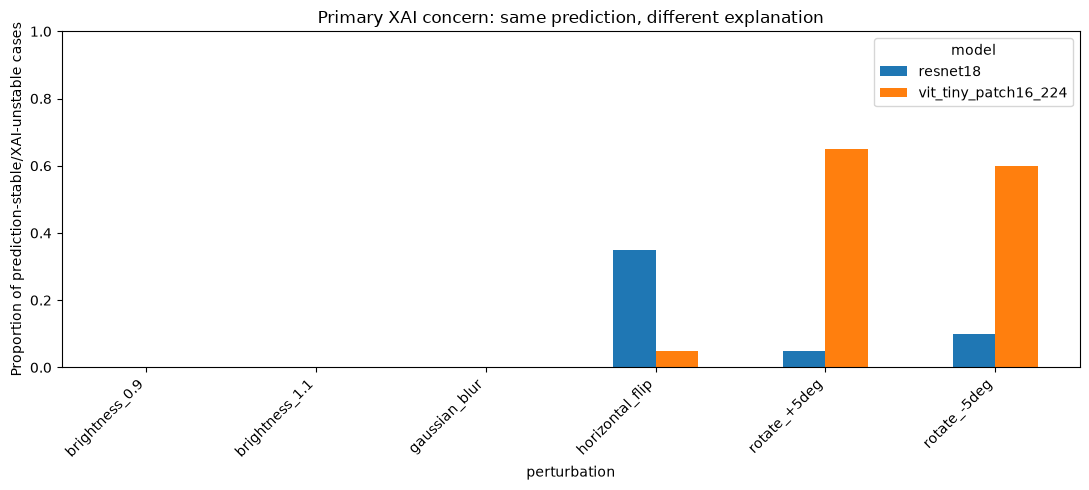

In [ ]:
# Define thresholds used to classify explanation stability
CORRELATION_THRESHOLD = 0.70
IOU_THRESHOLD = 0.50


# Mark an explanation as stable only when both similarity criteria are met
xai_raw_df["xai_stable"] = (
    (
        xai_raw_df["heatmap_correlation"]
        >= CORRELATION_THRESHOLD
    )
    &
    (
        xai_raw_df["top20_iou"]
        >= IOU_THRESHOLD
    )
)


def assign_stability_category(row):
    """Assign each sample to a joint prediction and XAI stability category."""

    # Both the prediction and explanation remain stable
    if (
        row["prediction_stable"]
        and row["xai_stable"]
    ):
        return "Prediction stable + XAI stable"

    # Prediction is unchanged but the explanation changes substantially
    if (
        row["prediction_stable"]
        and not row["xai_stable"]
    ):
        return "Prediction stable + XAI unstable"

    # Prediction changes while the explanation remains similar
    if (
        not row["prediction_stable"]
        and row["xai_stable"]
    ):
        return "Prediction changed + XAI stable"

    # Both the prediction and explanation change
    return "Prediction changed + XAI unstable"


# Assign a joint stability category to every model-perturbation observation
xai_raw_df["stability_category"] = (
    xai_raw_df.apply(
        assign_stability_category,
        axis=1
    )
)


# Count observations in each joint stability category
joint_counts = (
    xai_raw_df
    .groupby([
        "model",
        "perturbation",
        "stability_category"
    ])
    .size()
    .rename("count")
    .reset_index()
)


# Convert category counts into proportions within each model and perturbation
joint_counts["proportion"] = (
    joint_counts["count"]
    / joint_counts.groupby([
        "model",
        "perturbation"
    ])["count"].transform("sum")
)


# Arrange the joint stability proportions into a comparison table
joint_stability_table = (
    joint_counts
    .pivot_table(
        index=[
            "model",
            "perturbation"
        ],
        columns="stability_category",
        values="proportion",
        fill_value=0
    )
)

display(joint_stability_table)


# Most important problematic cases:
# prediction is unchanged, but explanation is unstable
same_prediction_unstable_xai = xai_raw_df[
    (xai_raw_df["prediction_stable"])
    &
    (~xai_raw_df["xai_stable"])
].copy()

print(
    "Cases with unchanged prediction "
    "but unstable explanation:",
    len(same_prediction_unstable_xai)
)

# Inspect the cases with the lowest explanation-stability measures
display(
    same_prediction_unstable_xai[
        [
            "image_index",
            "model",
            "perturbation",
            "class",
            "original_prediction",
            "heatmap_correlation",
            "heatmap_cosine",
            "top20_iou"
        ]
    ].sort_values(
        [
            "heatmap_correlation",
            "top20_iou"
        ]
    ).head(30)
)


# Select the category representing unchanged predictions with unstable explanations
problem_category = (
    "Prediction stable + XAI unstable"
)

# Plot how frequently this category occurs across perturbations
if problem_category in joint_stability_table.columns:
    joint_stability_table[
        problem_category
    ].unstack(0).plot(
        kind="bar",
        figsize=(11, 5),
        ylim=(0, 1)
    )

    plt.ylabel(
        "Proportion of prediction-stable/"
        "XAI-unstable cases"
    )

    plt.title(
        "Primary XAI concern: same prediction, "
        "different explanation"
    )

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def tensor_to_display_image(tensor):
    """
    Convert an ImageNet-normalized tensor into a displayable image.
    """

    # Recreate the ImageNet normalization parameters using the tensor dtype
    mean = torch.tensor(
        IMAGENET_MEAN,
        dtype=tensor.dtype
    )[:, None, None]

    std = torch.tensor(
        IMAGENET_STD,
        dtype=tensor.dtype
    )[:, None, None]

    # Reverse ImageNet normalization before converting to display format
    image = tensor.cpu() * std + mean

    # Keep pixel values valid and change from CHW to HWC format for matplotlib
    return image.clamp(0, 1).permute(
        1, 2, 0
    ).numpy()


def compare_xai_heatmaps(
    model_name,
    image_index,
    perturbation_name
):
    """
    Show original and perturbed explanations for one image.

    Columns:
    1. Original image
    2. Original explanation
    3. Perturbed image
    4. Perturbed explanation
    5. Aligned perturbed explanation
    6. Absolute explanation difference
    """

    # Validate the requested model and perturbation before running the comparison
    if model_name not in trained_models:
        raise KeyError(
            f"Model not found: {model_name}"
        )

    if perturbation_name not in PERTURBATIONS:
        raise KeyError(
            f"Unknown perturbation: {perturbation_name}"
        )

    model = trained_models[model_name]
    model.eval()

    # --------------------------------------------------------
    # Load original image
    # --------------------------------------------------------

    # Load the original test image and ensure a consistent RGB representation
    raw_image = Image.open(
        test_dataset.image_path(image_index)
    ).convert("RGB")

    # Retrieve the ground-truth diagnostic class
    true_label_idx = int(
        test_dataset.df.iloc[
            image_index
        ]["label_idx"]
    )

    # Apply the same preprocessing used during model evaluation
    original_tensor = base_transform(
        raw_image
    )

    original_input = original_tensor.unsqueeze(
        0
    ).to(device)

    # Obtain the model prediction for the original image
    original_prediction = predict_one(
        model,
        original_input
    )

    # Generate the original explanation using the original prediction
    original_heatmap, _ = explain(
        model_name,
        model,
        original_input,
        class_idx=original_prediction
    )

    # --------------------------------------------------------
    # Create perturbed image
    # --------------------------------------------------------

    # Retrieve the selected perturbation function
    perturbation_function = PERTURBATIONS[
        perturbation_name
    ]

    # Apply the perturbation before model preprocessing
    perturbed_raw_image = perturbation_function(
        raw_image.copy()
    )

    # Apply the standard preprocessing to the perturbed image
    perturbed_tensor = base_transform(
        perturbed_raw_image
    )

    perturbed_input = perturbed_tensor.unsqueeze(
        0
    ).to(device)

    # Obtain the prediction after perturbation
    perturbed_prediction = predict_one(
        model,
        perturbed_input
    )

    # Grad-CAM uses the original predicted class.
    # Attention rollout is class-agnostic.
    perturbed_heatmap, _ = explain(
        model_name,
        model,
        perturbed_input,
        class_idx=original_prediction
    )

    # --------------------------------------------------------
    # Align perturbed explanation to original coordinates
    # --------------------------------------------------------

    # Undo geometric transformations so the two explanations share coordinates
    aligned_heatmap = inverse_align_heatmap(
        perturbed_heatmap,
        perturbation_name
    )

    # Calculate the absolute spatial difference between explanations
    difference_heatmap = torch.abs(
        original_heatmap - aligned_heatmap
    )

    # Normalize the difference map for consistent visualization
    difference_heatmap = normalize_heatmap(
        difference_heatmap
    )

    # --------------------------------------------------------
    # Calculate similarity scores
    # --------------------------------------------------------

    # Quantify global and top-region similarity between explanations
    (
        correlation,
        cosine_similarity,
        top20_iou
    ) = heatmap_similarity(
        original_heatmap,
        aligned_heatmap,
        TOP_REGION_FRACTION
    )

    # Record whether the predicted class remained unchanged
    prediction_stable = (
        original_prediction
        == perturbed_prediction
    )

    # --------------------------------------------------------
    # Convert tensors for display
    # --------------------------------------------------------

    # Reverse normalization so the original image can be displayed correctly
    original_display = tensor_to_display_image(
        original_tensor
    )

    # Reverse normalization for the perturbed image as well
    perturbed_display = tensor_to_display_image(
        perturbed_tensor
    )

    # --------------------------------------------------------
    # Plot six comparison panels
    # --------------------------------------------------------

    # Use a six-panel layout to compare images, explanations, and differences
    fig, axes = plt.subplots(
        1,
        6,
        figsize=(24, 4)
    )

    # 1. Original image
    axes[0].imshow(original_display)
    axes[0].set_title(
        f"Original image\n"
        f"True: {class_names[true_label_idx]}\n"
        f"Pred: {class_names[original_prediction]}"
    )
    axes[0].axis("off")

    # 2. Original heatmap
    # Overlay the original explanation on the corresponding input image
    axes[1].imshow(original_display)
    axes[1].imshow(
        original_heatmap.numpy(),
        cmap="jet",
        alpha=0.45,
        vmin=0,
        vmax=1
    )
    axes[1].set_title("Original explanation")
    axes[1].axis("off")

    # 3. Perturbed image
    axes[2].imshow(perturbed_display)
    axes[2].set_title(
        f"{perturbation_name}\n"
        f"Pred: {class_names[perturbed_prediction]}"
    )
    axes[2].axis("off")

    # 4. Explanation in perturbed coordinates
    # Show the explanation before spatial alignment
    axes[3].imshow(perturbed_display)
    axes[3].imshow(
        perturbed_heatmap.numpy(),
        cmap="jet",
        alpha=0.45,
        vmin=0,
        vmax=1
    )
    axes[3].set_title("Perturbed explanation")
    axes[3].axis("off")

    # 5. Aligned explanation over original image
    # Overlay the spatially aligned perturbed explanation on the original image
    axes[4].imshow(original_display)
    axes[4].imshow(
        aligned_heatmap.numpy(),
        cmap="jet",
        alpha=0.45,
        vmin=0,
        vmax=1
    )
    axes[4].set_title(
        "Aligned perturbed\nexplanation"
    )
    axes[4].axis("off")

    # 6. Difference heatmap
    # Highlight locations where the two explanations differ most
    difference_plot = axes[5].imshow(
        difference_heatmap.numpy(),
        cmap="magma",
        vmin=0,
        vmax=1
    )
    axes[5].set_title(
        "Absolute difference\n"
        "Bright = larger change"
    )
    axes[5].axis("off")

    # Add a scale bar for the explanation-difference magnitude
    fig.colorbar(
        difference_plot,
        ax=axes[5],
        fraction=0.046,
        pad=0.04
    )

    # Convert the prediction comparison into a compact display label
    stability_text = (
        "Stable"
        if prediction_stable
        else "Changed"
    )

    # Identify the explanation method associated with each model
    method_name = (
        "Grad-CAM"
        if model_name == "resnet18"
        else "Attention Rollout"
    )

    # Summarize prediction and explanation stability in the figure title
    fig.suptitle(
        f"{model_name} — {method_name}\n"
        f"Prediction: {stability_text} | "
        f"Correlation: {correlation:.3f} | "
        f"Cosine: {cosine_similarity:.3f} | "
        f"Top-20% IoU: {top20_iou:.3f}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    # Return the numerical comparison results for further analysis or reporting
    return {
        "model": model_name,
        "image_index": image_index,
        "perturbation": perturbation_name,
        "true_class": class_names[true_label_idx],
        "original_prediction":
            class_names[original_prediction],
        "perturbed_prediction":
            class_names[perturbed_prediction],
        "prediction_stable": prediction_stable,
        "heatmap_correlation": correlation,
        "heatmap_cosine": cosine_similarity,
        "top20_iou": top20_iou
    }

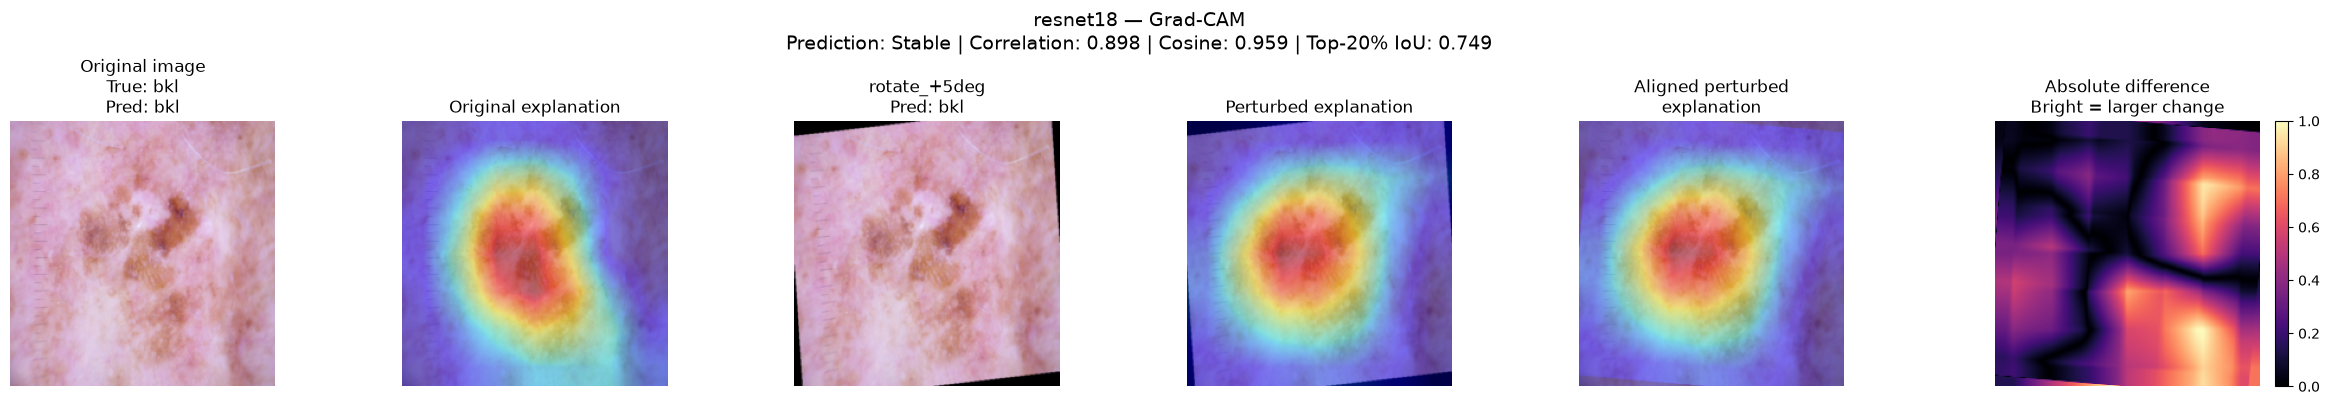

model                       resnet18
image_index                        0
perturbation            rotate_+5deg
true_class                       bkl
original_prediction              bkl
perturbed_prediction             bkl
prediction_stable               True
heatmap_correlation         0.898422
heatmap_cosine               0.95859
top20_iou                   0.749346
dtype: object

In [23]:
result = compare_xai_heatmaps(
    model_name="resnet18",
    image_index=0,
    perturbation_name="rotate_+5deg"
)

display(pd.Series(result))

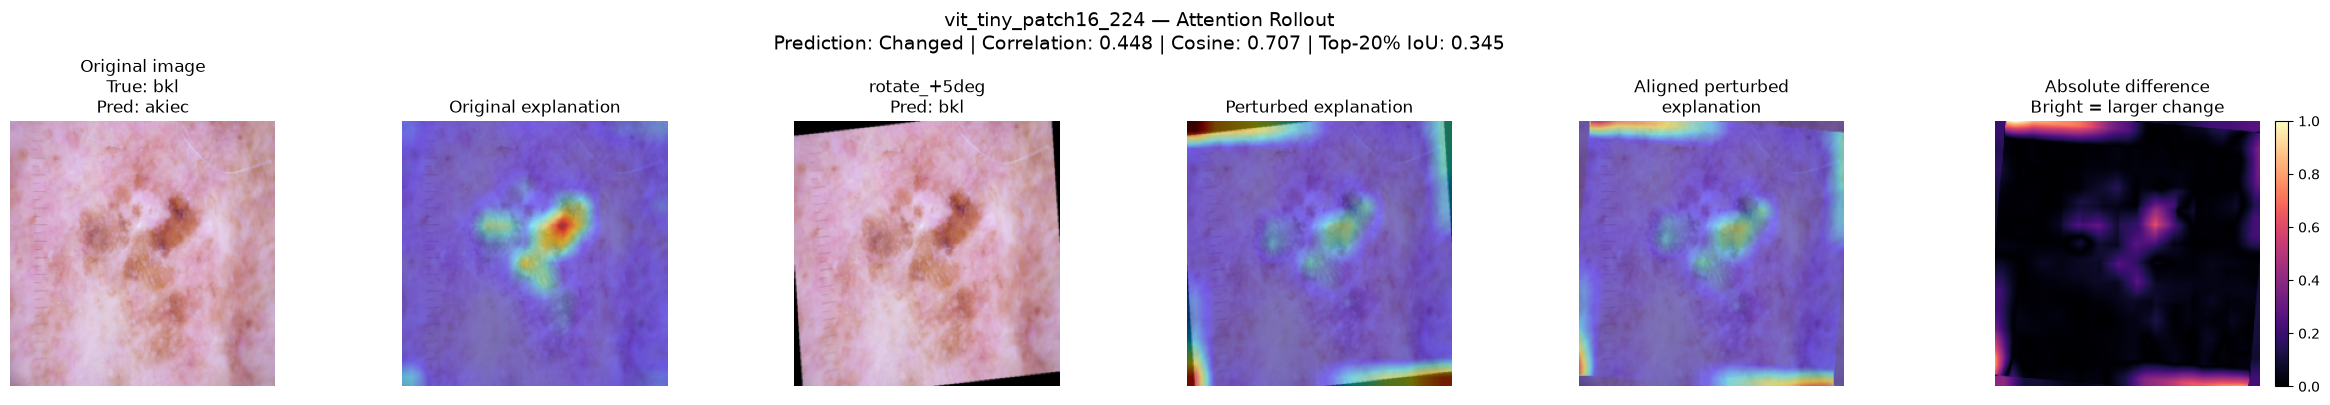

model                   vit_tiny_patch16_224
image_index                                0
perturbation                    rotate_+5deg
true_class                               bkl
original_prediction                    akiec
perturbed_prediction                     bkl
prediction_stable                      False
heatmap_correlation                 0.447575
heatmap_cosine                      0.707049
top20_iou                           0.344587
dtype: object

In [24]:
result = compare_xai_heatmaps(
    model_name="vit_tiny_patch16_224",
    image_index=0,
    perturbation_name="rotate_+5deg"
)

display(pd.Series(result))

,image_index,model,perturbation,class,original_prediction,heatmap_correlation,top20_iou
144,4,vit_tiny_patch16_224,rotate_-5deg,bkl,bkl,0.088333,0.200622
145,4,vit_tiny_patch16_224,rotate_+5deg,bkl,bkl,0.209719,0.202060
132,2,vit_tiny_patch16_224,rotate_-5deg,bkl,df,0.252201,0.280421
42,7,resnet18,rotate_-5deg,bkl,bkl,0.443809,0.185938
50,8,resnet18,horizontal_flip,bkl,bkl,0.542019,0.176346
62,10,resnet18,horizontal_flip,bkl,bkl,0.564144,0.279939


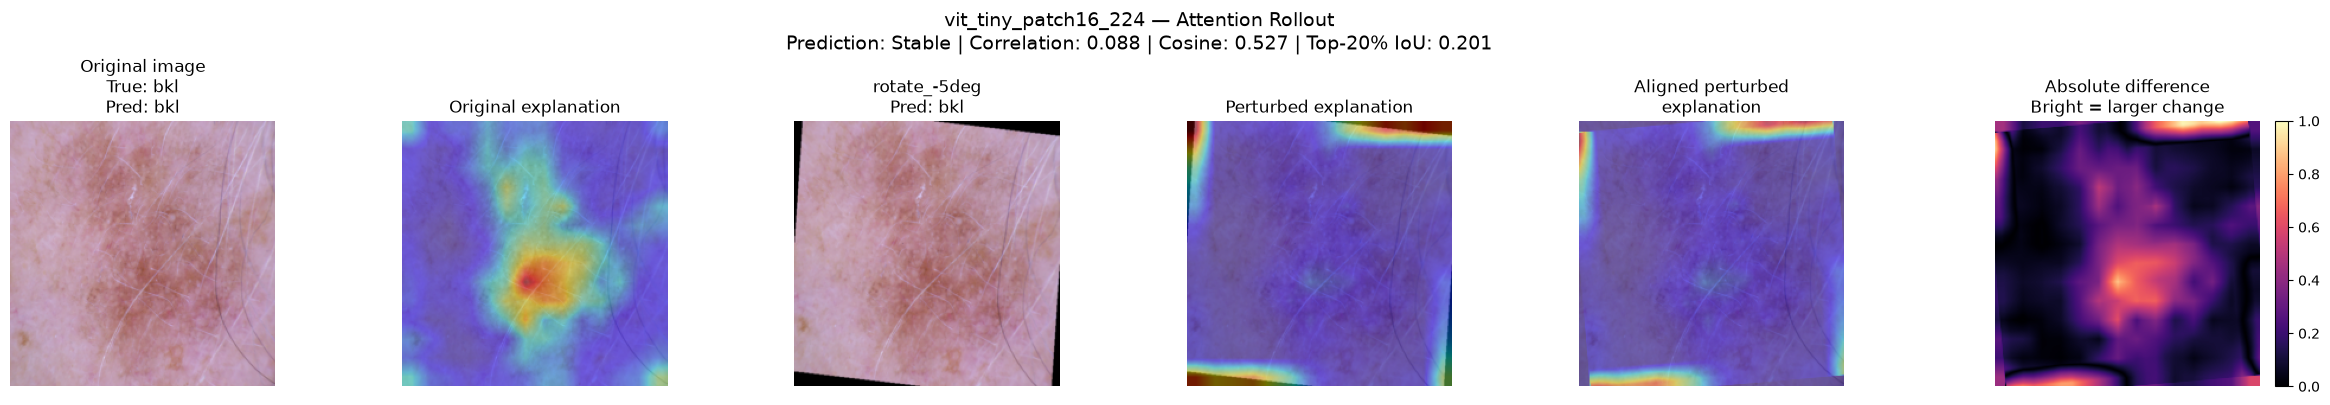

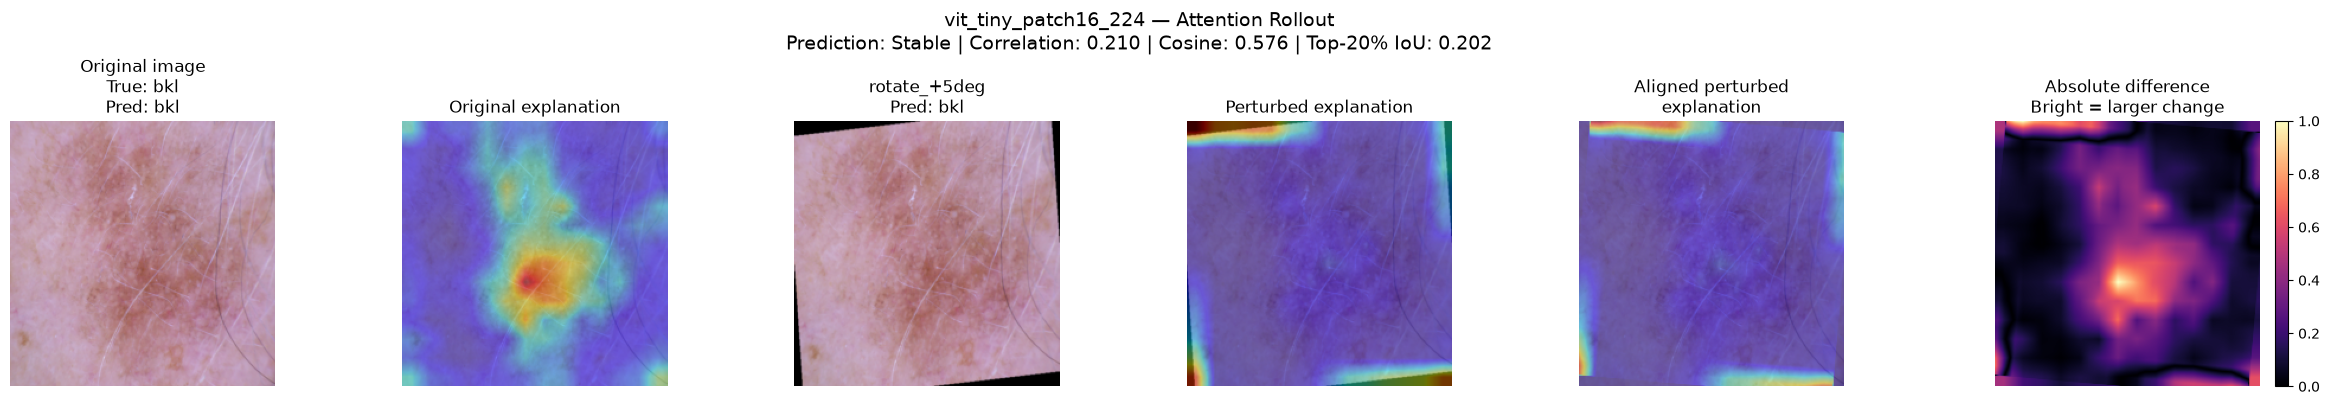

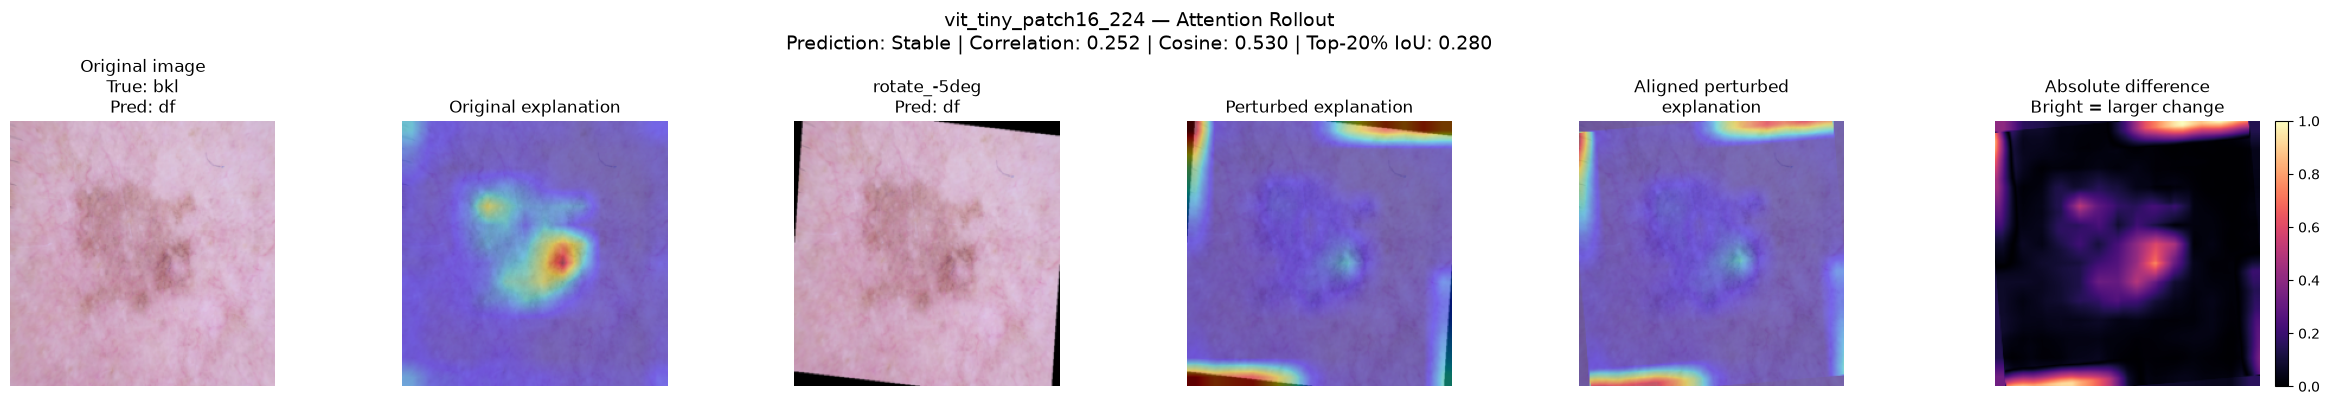

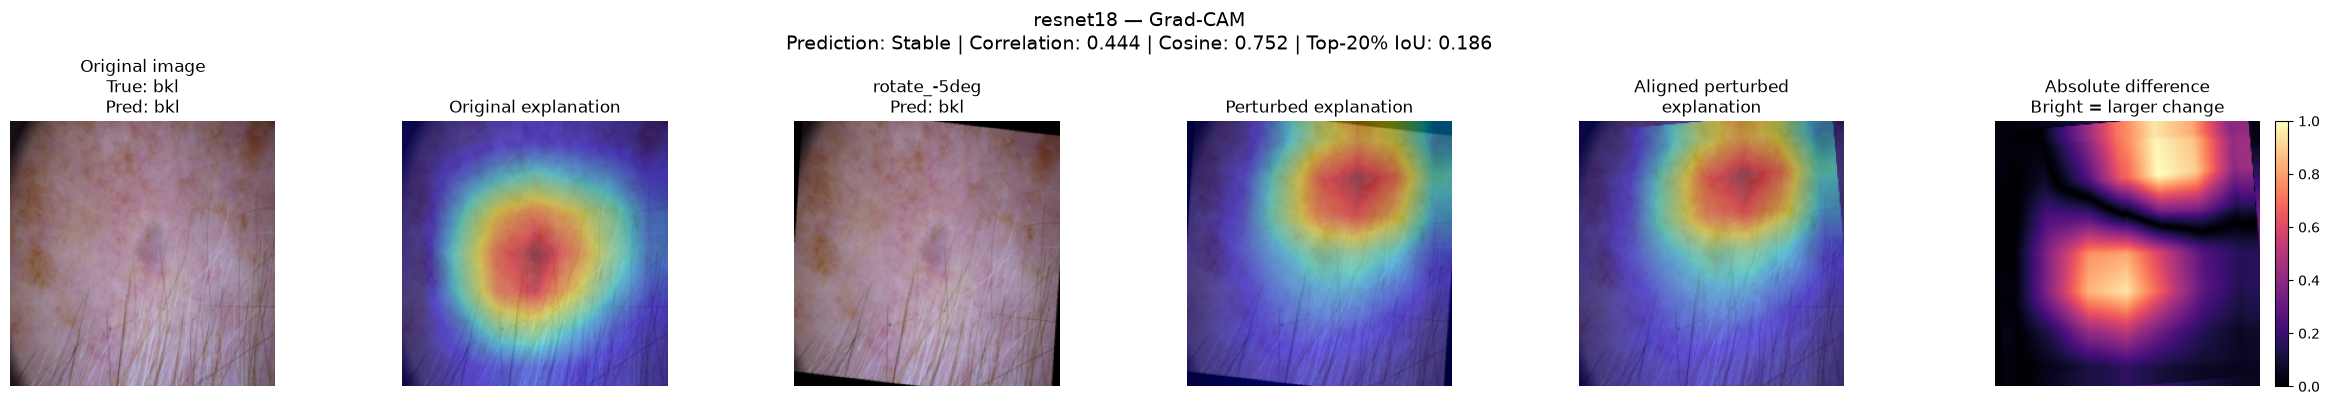

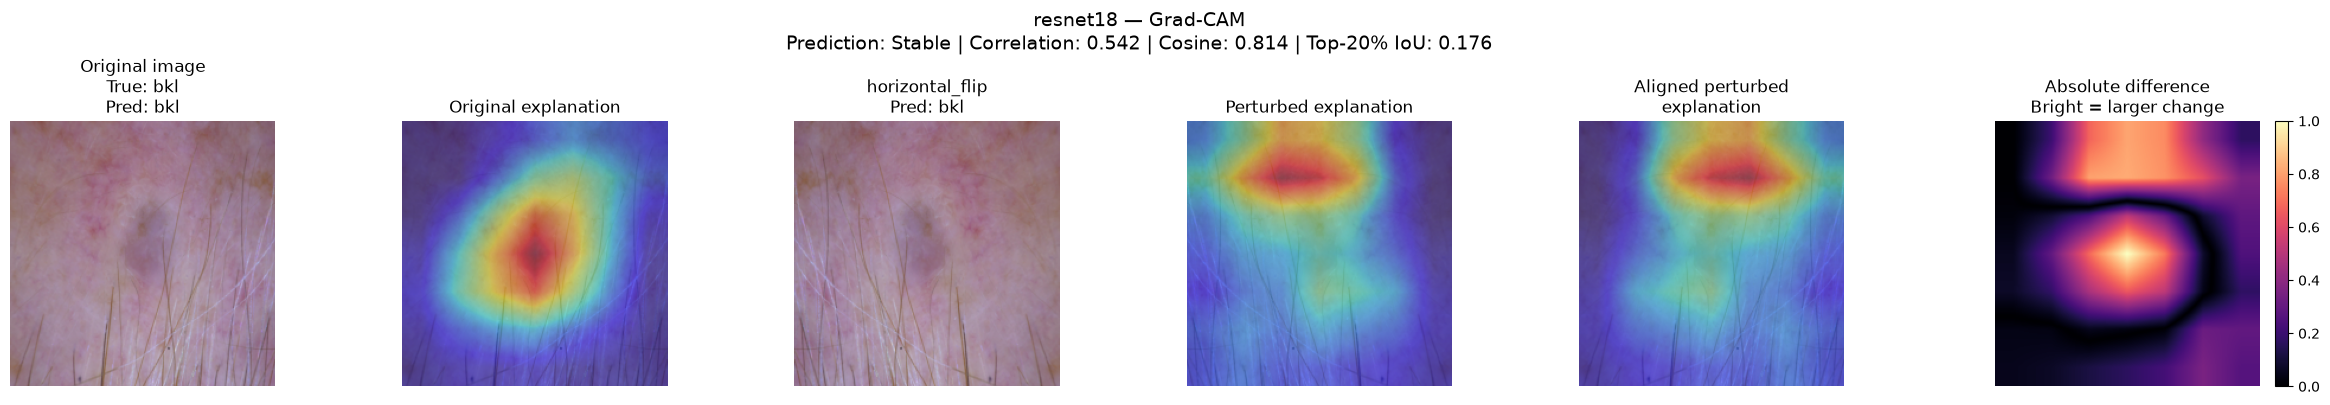

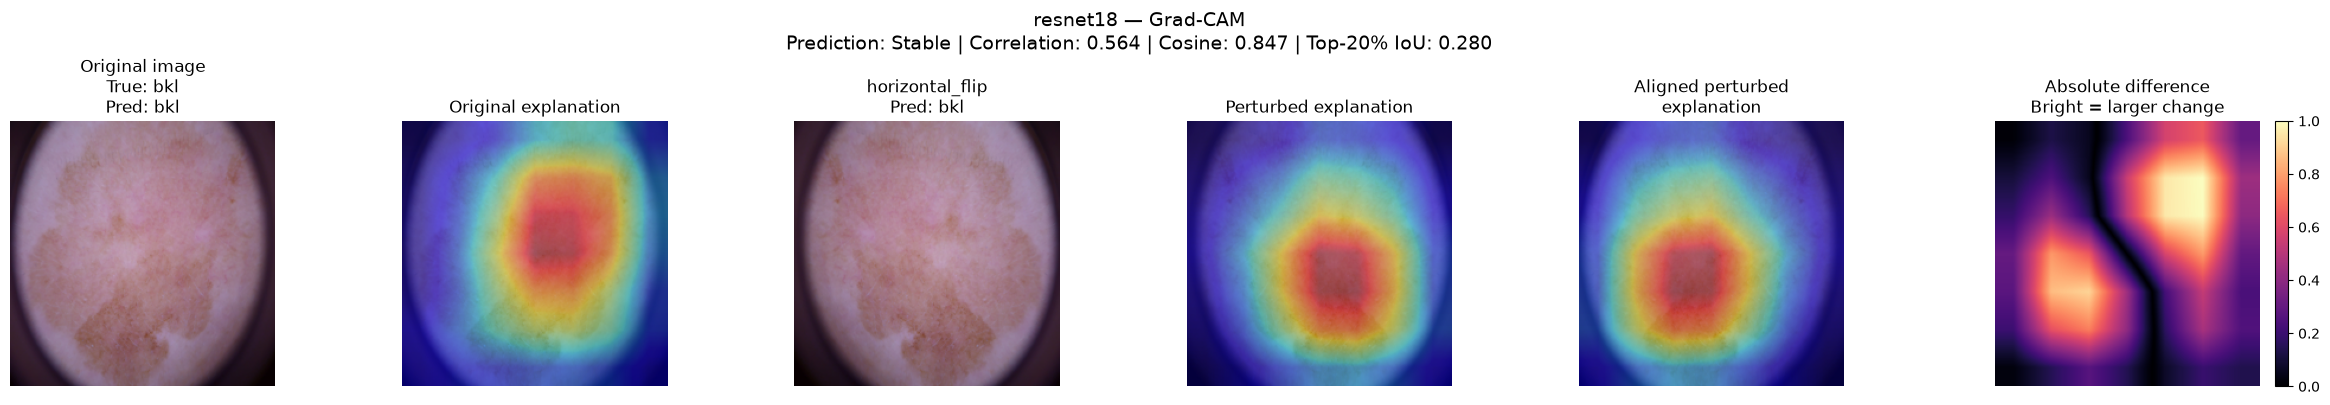

In [ ]:
# Select prediction-stable examples with the lowest explanation correlation
unstable_examples = (

    xai_raw_df[

        xai_raw_df["prediction_stable"]

    ]

    .sort_values(

        "heatmap_correlation",

        ascending=True

    )

    # Select the three most explanation-unstable examples for each model
    .groupby("model")

    .head(3)

)

# Display the key details of the selected examples
display(

    unstable_examples[

        [

            "image_index",

            "model",

            "perturbation",

            "class",

            "original_prediction",

            "heatmap_correlation",

            "top20_iou"

        ]

    ]

)

# Generate the six-panel XAI comparison for each selected example
for _, row in unstable_examples.iterrows():

    compare_xai_heatmaps(

        model_name=row["model"],

        image_index=int(row["image_index"]),

        perturbation_name=row["perturbation"]

    )
